# IBM QAOA Hardware Data Analysis

This notebook processes IBM QAOA **hardware quantum device measurements** exclusively and runs them through the stochastic benchmark framework. Hardware bitstrings from IBM quantum devices are evaluated against the MaxCut Hamiltonian to compute energies and approximation ratios.

**Note**: Simulation files are used only to extract the problem definition (cost_operator / Hamiltonian). All analysis is performed on hardware measurement data.

## Hardware Data Processing Pipeline

**Hardware QAOA measurements** are processed through the following pipeline:

1. **Instance Loading**: Load graph edges directly from instance files (N-based subdirectory structure)
2. **SAT Mapper Remapping**: Hardware bitstrings are measured in physical qubit order - remap to program qubit order using edge_map
3. **Cut Value Evaluation**: Evaluate MaxCut cut value for each bitstring: $C = \sum_{(i,j) \in E} w_{ij} \cdot (bit[i] \oplus bit[j])$
4. **Expectation Value**: Compute weighted average over measurement distribution (typically 100-1000 shots per trial)
5. **Method Separation**: Extract 8 independent methods per file (I_MPS_10, F_MPS_10, etc.) 
6. **Statistical Analysis**: Bootstrap and interpolation on hardware results

**Terminology**:
- **p (QAOA layers)**: Number of QAOA parameter layers, not circuit depth
- **Program qubits**: Qubits in problem Hamiltonian (before hardware mapping)
- **Physical qubits**: Actual hardware qubits (after SAT mapping)

## ⚠️ Approximation Ratio Fix Applied

**Issue**: Previous runs showed approximation ratios > 1 (impossible values like 2.46, 4.74)

**Root cause**: Code was treating `eval_energy` (QAOA expectation value) as a cut value directly

**Solution**: Applied canonical formula from `graph_utils.py`:
```python
cut_val = eval_energy + 0.5 * sum_weights
approx_ratio = (cut_val - min_cut) / (max_cut - min_cut)
```

**Expected results**: All approximation ratios should now be in [0, 1] range

**If you still see ratios > 1**: Restart the kernel and re-run all cells to reload the fixed code.

## ⚠️ Important: Updated Time Tracking

**The processing code has been updated with improved time tracking!**

The new version tracks **three time components**:
- `TrainTime`: Parameter training time (from simulation files)
- `SATMappingTime`: SAT mapper pre-processing time (from hardware files)
- `TotalTime`: Complete resource cost (TrainTime + SATMappingTime)

**To use the new time tracking:**
1. Re-run the data processing cell (Step 3) to regenerate `agg_df` with new columns
2. The analysis cells will automatically detect and use the new time columns
3. You can configure which time component to use for performance analysis

**If you skip re-processing:** The notebook will continue to work with the old `MeanTime` column (which used only one time component instead of summing both).

## 1. Import Required Libraries

Import necessary libraries for hardware data processing, including bitstring energy evaluation and qubit remapping utilities.

In [1]:
import json
import os
import glob
import sys
import re
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
from typing import Dict, List, Any
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import matplotlib.cm as cm
import matplotlib.colors as mcolors


# Set up matplotlib style
plt.style.use('../../src/ws.mplstyle')

# Add stochastic-benchmark src to path
sys.path.append('../../src')

# Import stochastic benchmark modules
import stochastic_benchmark
import bootstrap
import success_metrics
import interpolate
from interpolate import Interpolate
import stats
import training

# Import local processing script
import ibm_qaoa_processing

# Explicitly reload to pick up fixes (especially approximation ratio fix)
import importlib
importlib.reload(ibm_qaoa_processing)

print("Libraries imported successfully!")
print("ibm_qaoa_processing reloaded with approximation ratio fix")

%load_ext autoreload
%autoreload 2

Libraries imported successfully!
ibm_qaoa_processing reloaded with approximation ratio fix


In [2]:
# Verify the approximation ratio fix is loaded
import inspect
source = inspect.getsource(ibm_qaoa_processing.parse_hardware_trial)
if 'cut_val = mean_energy + 0.5 * sum_weights' in source:
    print("✅ Approximation ratio FIX is loaded correctly!")
    print("   Using canonical formula: cut_val = energy + 0.5 * sum_weights")
else:
    print("⚠️  WARNING: Old version of code detected!")
    print("   Please restart kernel and re-run imports to load the fix.")

✅ Approximation ratio FIX is loaded correctly!
   Using canonical formula: cut_val = energy + 0.5 * sum_weights


In [3]:
# === CONFIGURATION: Select Topology and Node Count ===
selected_topology = "heavy_hex"  # Options: "R3R" (random 3-regular) or "heavy_hex"
selected_n = 144 

# Automatically set result directories based on topology
if selected_topology == "R3R":
    results_dir = "R3R_results"
    results_dir_hardware = "R3R_results_hardware"
elif selected_topology == "heavy_hex":
    results_dir = "heavy_hex_results"
    results_dir_hardware = "heavy_hex_results_hardware"
else:
    raise ValueError(f"Unknown topology: {selected_topology}. Use 'R3R' or 'heavy_hex'")

print(f"Configuration:")
print(f"  Topology: {selected_topology}")
print(f"  Selected node count (N): {selected_n}")
print(f"  Hardware data path: {selected_topology}/Hardware/N{selected_n}/")
print(f"  Instances path: instances/{selected_topology.lower().replace('_', '_')}/N{selected_n}/")
print(f"  Minmax cuts path: {selected_topology}/minmax_cuts/N{selected_n}/")
print(f"  Results directory (hardware): {results_dir_hardware}/")

# Verify the directories exist
import os
hardware_dir = f"{selected_topology}/Hardware/N{selected_n}"
if os.path.exists(hardware_dir):
    files = glob.glob(f"{hardware_dir}/*.json")
    print(f"\n✓ Found {len(files)} hardware JSON files in {hardware_dir}/")
    if len(files) <= 10:
        for f in files:
            print(f"  - {os.path.basename(f)}")
    else:
        print(f"  (showing first 5)")
        for f in files[:5]:
            print(f"  - {os.path.basename(f)}")
else:
    print(f"\n✗ ERROR: Directory {hardware_dir}/ not found!")
    print("Available directories:")
    for d in glob.glob(f"{selected_topology}/Hardware/*/"):
        print(f"  - {d}")

# Verify simulation directories (N-based subdirectories only)
print(f"\nSimulation files (N={selected_n}):")
for method in ['F', 'FA', 'I', 'TQA', 'TS', 'RTS']:
    sim_dir = f"{selected_topology}/{method}/N{selected_n}"
    if os.path.exists(sim_dir):
        count = len(glob.glob(f"{sim_dir}/*.json"))
        print(f"  {method}: {count} files")
    else:
        print(f"  {method}: Not found")

# Verify minmax cuts (N-based subdirectory required)
minmax_dir = f"{selected_topology}/minmax_cuts/N{selected_n}"
if os.path.exists(minmax_dir):
    count = len(glob.glob(f"{minmax_dir}/*.json"))
    print(f"\nMinmax cuts: {count} files in N{selected_n}/ subdirectory")
else:
    print(f"\n✗ ERROR: Minmax cuts not found in {minmax_dir}/")
    print("   N-based subdirectory structure is required (e.g., minmax_cuts/N40/)")

Configuration:
  Topology: heavy_hex
  Selected node count (N): 144
  Hardware data path: heavy_hex/Hardware/N144/
  Instances path: instances/heavy_hex/N144/
  Minmax cuts path: heavy_hex/minmax_cuts/N144/
  Results directory (hardware): heavy_hex_results_hardware/

✓ Found 20 hardware JSON files in heavy_hex/Hardware/N144/
  (showing first 5)
  - 000N144HH73_10_d4am2jq489vs73a2kc4g.json
  - 000N144HH73_5_d4am1h7nmdfs73ad2p90.json
  - 001N144HH73_10_d4mkp3s3tdfc73dqio10.json
  - 001N144HH73_5_d4mkjm90i6jc73dgt05g.json
  - 002N144HH73_10_d4mkpf574pkc738946i0.json

Simulation files (N=144):
  F: 20 files
  FA: Not found
  I: 20 files
  TQA: 40 files
  TS: Not found
  RTS: Not found

Minmax cuts: 10 files in N144/ subdirectory


## 2. Configuration: Select Topology and Node Count

Configure which topology and hardware dataset to analyze. All data (hardware, simulation, minmax cuts) is organized by topology and N value for consistent access.

**Available Topologies:**
- **R3R** (Random 3-Regular): Available N=20, 40, 60, 70
- **heavy_hex** (Heavy Hex): Available N=39, 105, 106, 144

**Recommended Configurations:**
- **R3R, N=40**: 34 hardware files (instances 000-009, depths: 3,4,5,10), 1560 simulation files, 10 minmax cuts ✅
- **heavy_hex, N=105**: 20 hardware files (instances 000-009, depths: 5,10), simulation files, 10 minmax cuts ✅
- **heavy_hex, N=144**: 20 hardware files (instances 000-009, depths: 5,10), simulation files, 10 minmax cuts ✅

**Data paths** (auto-configured by `selected_topology` and `selected_n`):

In [4]:
# Process Hardware QAOA data
# This handles hardware JSON parsing, bitstring energy evaluation, and DataFrame conversion
# Hardware mode: Loads Hamiltonians from simulation files, evaluates bitstring measurements, computes energies and approximation ratios
sb, agg_df = ibm_qaoa_processing.process_qaoa_data(
    json_pattern=f"{selected_topology}/Hardware/N{selected_n}/*.json",  # Use configured topology and node count
    output_dir=f"{results_dir_hardware}/exp_raw_hardware_N{selected_n}",
    minmax_dir=f"{selected_topology}/minmax_cuts",  # Use topology-specific minmax cuts directory
    hardware_mode=True  # Enable hardware processing with bitstring energy evaluation
)

# # *** FILTER OUT p=4 DATA (known energy convention issue causing ratios > 1.0) ***
# if 'p' in agg_df.columns:
#     original_count = len(agg_df)
#     agg_df = agg_df[agg_df['p'] != 4].copy()
#     print(f"\n*** Filtered out p=4 data ({original_count - len(agg_df)} rows removed due to energy convention issue) ***")

2026-01-28 08:40:28,258 - ibm_qaoa_processing - INFO - Processing in HARDWARE MODE - analyzing quantum device measurements
2026-01-28 08:40:28,266 - ibm_qaoa_processing - INFO - Found 20 hardware JSON files.
2026-01-28 08:40:28,268 - ibm_qaoa_processing - INFO - Detected N=144 from hardware filename, loading matching minmax cuts
2026-01-28 08:40:28,278 - ibm_qaoa_processing - INFO - Loading 10 minmax cut files from heavy_hex/minmax_cuts/N144
2026-01-28 08:40:28,612 - ibm_qaoa_processing - INFO - Loaded minmax cuts data for 10 instances
2026-01-28 08:40:28,613 - ibm_qaoa_processing - INFO - Minmax cuts loaded: 10 instances available for N=144
2026-01-28 08:40:38,115 - ibm_qaoa_processing - INFO - Processed 10/20 hardware files...
2026-01-28 08:40:47,438 - ibm_qaoa_processing - INFO - Processed 20/20 hardware files...
2026-01-28 08:40:47,452 - ibm_qaoa_processing - INFO - Hardware processing complete: 120 total trials
2026-01-28 08:40:47,477 - ibm_qaoa_processing - INFO - Skipping interp

**IMPORTANT NOTE**: After running with the approximation ratio fix:
- **Expected range**: Approximation ratios should be in [0, 1]
- **Previous issue**: Old code showed ratios > 1 (e.g., 2.46, 4.74) because it didn't apply the canonical transformation
- **Fix applied**: Now uses `cut_val = energy + 0.5 * sum_weights` from graph_utils.py

If you still see ratios > 1, **restart the kernel** and re-run from the import cell to reload the fixed code.

IBM Quantum Hardware QAOA: Performance Ratio Analysis

Training Time Data:
  Total trials: 120
  Valid training times: 120/120 (100.0%)
  Using 120 trials for time-based analysis


Statistics by p (depth):
 p     mean      std  count      min      max
 5 0.789493 0.101470     60 0.552104 0.915129
10 0.801605 0.123719     60 0.547067 0.952032

Data Point Counts by Depth:
  p=5: 60 data points
  p=10: 60 data points


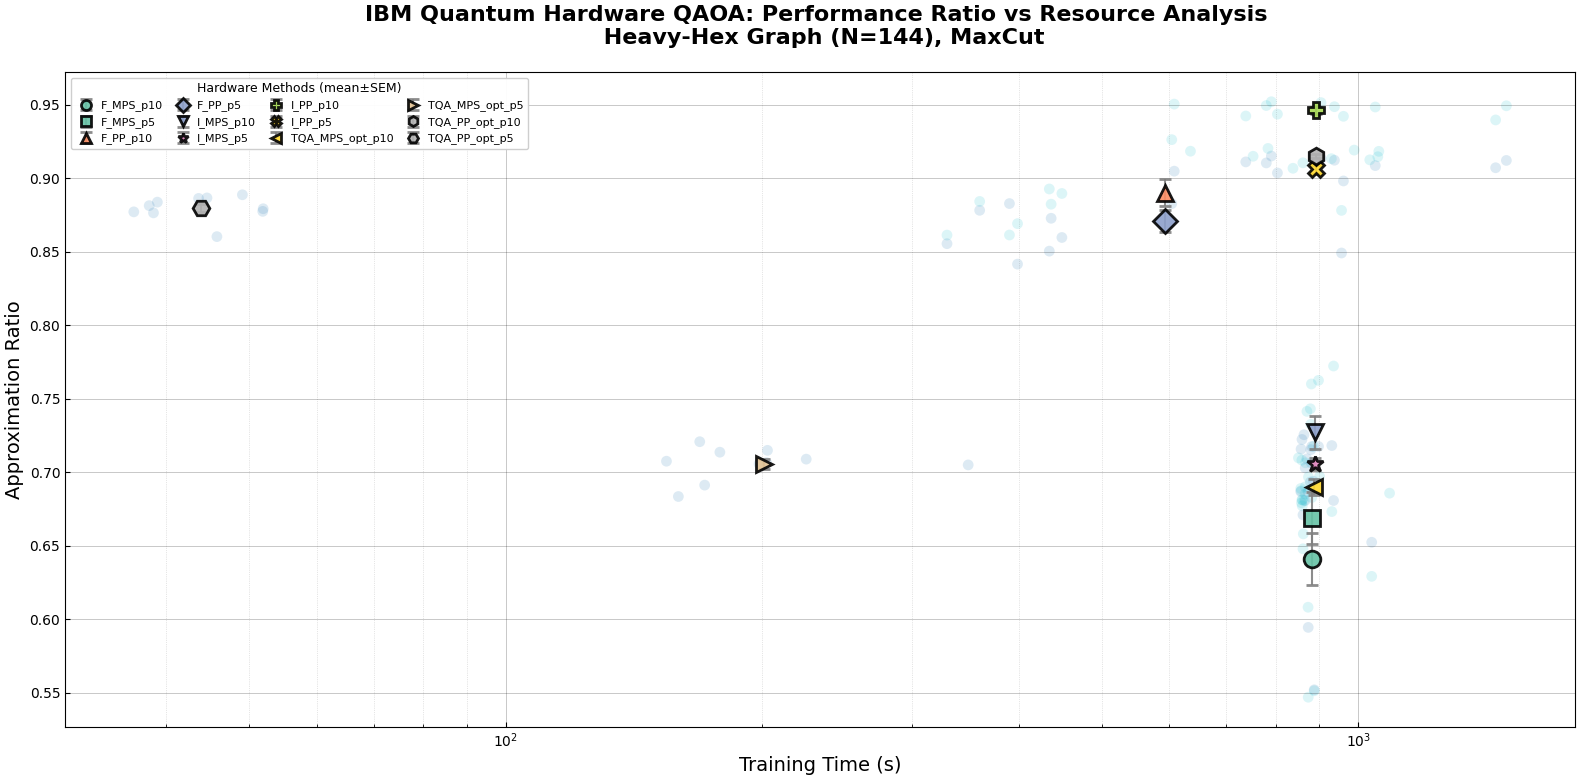


Hardware Results Summary
Total hardware trials: 120
Unique instances: 10
Methods tested: ['F_MPS', 'F_PP', 'I_MPS', 'I_PP', 'TQA_MPS_opt', 'TQA_PP_opt']
p values tested: [5, 10]

Overall Hardware Performance:
  Mean approximation ratio: 0.7955 ± 0.1128
  Best result: 0.9520
  Worst result: 0.5471

Per-p Performance:
  p=5: 0.7895 ± 0.1015 [0.5521, 0.9151] (n=60)
  p=10: 0.8016 ± 0.1237 [0.5471, 0.9520] (n=60)


In [5]:
# === Hardware Method Analysis: Performance Ratio vs Training Time ===
print("=" * 80)
print("IBM Quantum Hardware QAOA: Performance Ratio Analysis")
print("=" * 80)

# Filter to show only hardware results
if 'method' not in agg_df.columns:
    print("Warning: 'method' column not found. Using trainer instead.")
    agg_df['method'] = agg_df['trainer']

# Check and report training time data availability
total_trials = len(agg_df)
valid_time_trials = (agg_df['MeanTime'].notna() & (agg_df['MeanTime'] > 0)).sum()
zero_times = (agg_df['MeanTime'] == 0.0).sum()
missing_times = agg_df['MeanTime'].isna().sum()

print(f"\nTraining Time Data:")
print(f"  Total trials: {total_trials}")
print(f"  Valid training times: {valid_time_trials}/{total_trials} ({100*valid_time_trials/total_trials:.1f}%)")
if zero_times > 0:
    print(f"  Zero training times (missing simulation data): {zero_times}")
    zero_methods = agg_df[agg_df['MeanTime'] == 0.0]['method'].unique()
    print(f"    Methods affected: {sorted(zero_methods)}")
if missing_times > 0:
    print(f"  NaN training times: {missing_times}")

# Filter out rows with missing or zero training times for plotting
agg_df_with_time = agg_df[(agg_df['MeanTime'].notna()) & (agg_df['MeanTime'] > 0)].copy()
print(f"  Using {len(agg_df_with_time)} trials for time-based analysis\n")

# Create combined method-p label for unique identification
agg_df_with_time['method_p'] = agg_df_with_time['method'] + '_p' + agg_df_with_time['p'].astype(int).astype(str)

# Calculate centroids and SEM for each method-p combination (using filtered data)
method_stats = agg_df_with_time.groupby(['method', 'p', 'method_p']).agg({
    'MeanTime': ['mean', 'std', 'count'],
    'Approximation_Ratio': ['mean', 'std', 'count']
}).reset_index()
method_stats.columns = ['method', 'p', 'method_p', 'mean_time', 'std_time', 'count_time', 'mean_ratio', 'std_ratio', 'count_ratio']

# Calculate standard error of the mean (SEM = std / sqrt(n))
method_stats['sem_time'] = method_stats['std_time'] / np.sqrt(method_stats['count_time'])
method_stats['sem_ratio'] = method_stats['std_ratio'] / np.sqrt(method_stats['count_ratio'])

# Calculate statistics by depth for summary
stats_by_depth = agg_df.groupby('p')['Approximation_Ratio'].agg([
    ('mean', 'mean'),
    ('std', 'std'),
    ('count', 'count'),
    ('min', 'min'),
    ('max', 'max')
]).reset_index()

print("\nStatistics by p (depth):")
print(stats_by_depth.to_string(index=False))

# Check data counts per depth
print("\n" + "="*80)
print("Data Point Counts by Depth:")
for p_val in sorted(agg_df['p'].unique()):
    count = len(agg_df[agg_df['p'] == p_val])
    print(f"  p={int(p_val)}: {count} data points")
print("="*80)

# Create plot with all data points and method centroids with error bars
fig, ax = plt.subplots(figsize=(16, 8))

depths = sorted(agg_df_with_time['p'].unique())
# Use method_p combinations for unique labels
method_p_combos = sorted(method_stats['method_p'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(depths)))

# Marker styles for variety
markers = ['o', 's', '^', 'D', 'v', '*', 'P', 'X', '<', '>', 'h', 'H']

# First pass: Plot all individual data points (NO LABELS - just show by color)
for i, depth in enumerate(depths):
    depth_data = agg_df_with_time[agg_df_with_time['p'] == depth]
    n_points = len(depth_data)
    if n_points > 0:
        z_order = 1 if n_points > 20 else 2
        alpha = 0.15 if n_points > 20 else 0.35
        size = 60 if n_points > 20 else 80
        
        ax.scatter(
            depth_data['MeanTime'],
            depth_data['Approximation_Ratio'],
            alpha=alpha,
            s=size,
            color=colors[i],
            marker='o',
            edgecolors='none',
            zorder=z_order
        )

# Second pass: Plot method-p centroids with error bars (WITH LABELS)
# Use different colors for each unique method-p combination
method_p_colors = plt.cm.Set2(np.linspace(0, 1, len(method_p_combos)))
for i, method_p in enumerate(method_p_combos):
    method_data = method_stats[method_stats['method_p'] == method_p]
    if len(method_data) > 0:
        ax.errorbar(
            method_data['mean_time'],
            method_data['mean_ratio'],
            yerr=method_data['sem_ratio'],
            fmt=markers[i % len(markers)],
            markersize=12,
            markerfacecolor=method_p_colors[i],
            markeredgecolor='black',
            markeredgewidth=2,
            ecolor='gray',
            elinewidth=1.5,
            capsize=4,
            capthick=1.5,
            alpha=0.9,
            label=method_p,
            zorder=10
        )

ax.set_xlabel('Training Time (s)', fontsize=14)
ax.set_ylabel('Approximation Ratio', fontsize=14)
ax.set_title(f'IBM Quantum Hardware QAOA: Performance Ratio vs Resource Analysis \n Heavy-Hex Graph (N={selected_n}), MaxCut',
          fontsize=16, fontweight='bold', pad=20)
ax.set_xscale('log')

ax.grid(True, linestyle='-', alpha=0.3, which='major')
ax.grid(True, linestyle=':', alpha=0.2, which='minor')

# Legend with smaller marker icons and 4 columns
legend = ax.legend(fontsize=8, 
                   title='Hardware Methods (mean±SEM)', 
                   title_fontsize=9, 
                   loc='upper left', 
                   framealpha=0.95, 
                   ncol=4,
                   columnspacing=0.8, 
                   handletextpad=0.3,
                   markerscale=0.6)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 80)
print("Hardware Results Summary")
print("=" * 80)
print(f"Total hardware trials: {len(agg_df)}")
print(f"Unique instances: {agg_df['instance'].nunique()}")
print(f"Methods tested: {sorted(agg_df['method'].unique())}")
print(f"p values tested: {sorted(agg_df['p'].unique())}")
print(f"\nOverall Hardware Performance:")
print(f"  Mean approximation ratio: {agg_df['Approximation_Ratio'].mean():.4f} ± {agg_df['Approximation_Ratio'].std():.4f}")
print(f"  Best result: {agg_df['Approximation_Ratio'].max():.4f}")
print(f"  Worst result: {agg_df['Approximation_Ratio'].min():.4f}")
print("\nPer-p Performance:")
for _, row in stats_by_depth.iterrows():
    print(f"  p={int(row['p'])}: {row['mean']:.4f} ± {row['std']:.4f} "
          f"[{row['min']:.4f}, {row['max']:.4f}] (n={int(row['count'])})")

## Hardware Method Comparison Analysis

Compare all hardware methods as independent training strategies. Each method is treated separately without hierarchical grouping.

In [6]:
# === Hardware Method Statistics ===
print("="*80)
print("IBM Quantum Hardware QAOA Analysis - All Methods as Independent Strategies")
print("="*80)

# Get unique methods from hardware data
if 'method' in agg_df.columns:
    hardware_methods = sorted(agg_df['method'].unique())
    print(f"\nHardware methods found: {hardware_methods}")
    print(f"Total methods: {len(hardware_methods)}")
    
    # Statistics per method - include all time columns if available
    agg_dict = {
        'instance': 'nunique',
        'p': lambda x: list(sorted(x.unique())),
        'Approximation_Ratio': ['mean', 'std', 'min', 'max', 'count']
    }
    
    # Add time columns that exist in the dataframe
    if 'TotalTime' in agg_df.columns:
        agg_dict['TotalTime'] = ['mean', 'std', 'min', 'max']
    if 'TrainTime' in agg_df.columns:
        agg_dict['TrainTime'] = ['mean', 'std', 'min', 'max']
    if 'SATMappingTime' in agg_df.columns:
        agg_dict['SATMappingTime'] = ['mean', 'std', 'min', 'max']
    if 'MeanTime' in agg_df.columns and 'TotalTime' not in agg_df.columns:
        # Only show MeanTime if new columns aren't available
        agg_dict['MeanTime'] = ['mean', 'std', 'min', 'max']
    
    method_summary = agg_df.groupby('method').agg(agg_dict).round(4)
    
    print("\n" + "="*80)
    print("Method Summary Statistics")
    print("="*80)
    display(method_summary)
else:
    print("\nWarning: 'method' column not found in hardware data")
    hardware_methods = []

IBM Quantum Hardware QAOA Analysis - All Methods as Independent Strategies

Hardware methods found: ['F_MPS', 'F_PP', 'I_MPS', 'I_PP', 'TQA_MPS_opt', 'TQA_PP_opt']
Total methods: 6

Method Summary Statistics


instance        p Approximation_Ratio                          \
             nunique <lambda>                mean     std     min     max   
method                                                                      
F_MPS             10  [5, 10]              0.6551  0.0564  0.5471  0.7256   
F_PP              10  [5, 10]              0.8805  0.0277  0.8416  0.9423   
I_MPS             10  [5, 10]              0.7163  0.0284  0.6733  0.7723   
I_PP              10  [5, 10]              0.9262  0.0222  0.8827  0.9520   
TQA_MPS_opt       10  [5, 10]              0.6979  0.0159  0.6582  0.7208   
TQA_PP_opt        10  [5, 10]              0.8973  0.0191  0.8603  0.9203   

                  TotalTime                                TrainTime  \
            count      mean       std       min        max      mean   
method                                                                 
F_MPS          20  883.8117   53.3357  856.4702  1037.3079  883.8117   
F_PP           20  594.1702  349.4938  329.3948  1449.7813  594.1702   
I_MPS          20  891.2165   23.2519  866.8065   935.7692  891.2165   
I_PP           20  893.1751  248.1688  604.4575  1492.4016  893.1751   
TQA_MPS_opt    20  544.5932  358.1121  154.3922  1088.6116  544.5932   
TQA_PP_opt     20  468.7896  446.9073   36.6256  1057.4437  468.7896   

                                           SATMappingTime                 
                  std       min        max           mean  std  min  max  
method                                                                    
F_MPS         53.3357  856.4702  1037.3079            0.0  0.0  0.0  0.0  
F_PP         349.4938  329.3948  1449.7813            0.0  0.0  0.0  0.0  
I_MPS         23.2519  866.8065   935.7692            0.0  0.0  0.0  0.0  
I_PP         248.1688  604.4575  1492.4016            0.0  0.0  0.0  0.0  
TQA_MPS_opt  358.1121  154.3922  1088.6116            0.0  0.0  0.0  0.0  
TQA_PP_opt   446.9073   36.6256  1057.4437            0.0  0.0  0.0  0.0

## Time Tracking Analysis

The processing now tracks three time components:
- **TrainTime**: Parameter training from simulation files (classical optimization)
- **SATMappingTime**: SAT mapper pre-processing from hardware (qubit mapping)
- **TotalTime**: Complete resource cost (TrainTime + SATMappingTime)

This enables analysis of which time component dominates resource usage.

In [7]:
# === Time Component Breakdown ===
print("="*80)
print("Time Component Analysis")
print("="*80)

# Check which time columns are available
time_cols = [col for col in agg_df.columns if 'Time' in col]
print(f"\nAvailable time columns: {time_cols}")

if 'TrainTime' in agg_df.columns and 'SATMappingTime' in agg_df.columns and 'TotalTime' in agg_df.columns:
    print("\n✅ New time tracking is active!")
    
    # Summary statistics for each time component
    time_summary = pd.DataFrame({
        'TrainTime (sec)': [
            agg_df['TrainTime'].mean(),
            agg_df['TrainTime'].std(),
            agg_df['TrainTime'].min(),
            agg_df['TrainTime'].max()
        ],
        'SATMappingTime (sec)': [
            agg_df['SATMappingTime'].mean(),
            agg_df['SATMappingTime'].std(),
            agg_df['SATMappingTime'].min(),
            agg_df['SATMappingTime'].max()
        ],
        'TotalTime (sec)': [
            agg_df['TotalTime'].mean(),
            agg_df['TotalTime'].std(),
            agg_df['TotalTime'].min(),
            agg_df['TotalTime'].max()
        ]
    }, index=['Mean', 'Std', 'Min', 'Max'])
    
    print("\nTime Component Statistics:")
    display(time_summary.round(4))
    
    # Calculate percentage contribution of each component
    total_train = agg_df['TrainTime'].sum()
    total_sat = agg_df['SATMappingTime'].sum()
    total_all = agg_df['TotalTime'].sum()
    
    print(f"\nTime Contribution Breakdown:")
    print(f"  TrainTime:       {total_train:.2f}s ({100*total_train/total_all:.1f}%)")
    print(f"  SATMappingTime:  {total_sat:.2f}s ({100*total_sat/total_all:.1f}%)")
    print(f"  TotalTime:       {total_all:.2f}s (100%)")
    
    # Compare by topology
    if selected_topology == "heavy_hex":
        print(f"\nNote: heavy_hex topology uses identity mapping (SATMappingTime ≈ 0)")
    else:
        print(f"\nNote: R3R topology requires SAT mapping (SATMappingTime > 0)")
        
else:
    print("\n⚠️  Old time tracking detected - only MeanTime available")
    print("   Re-process data with updated ibm_qaoa_processing.py to get time breakdown")

Time Component Analysis

Available time columns: ['TrainTime', 'SATMappingTime', 'TotalTime', 'MeanTime']

✅ New time tracking is active!

Time Component Statistics:


,TrainTime (sec),SATMappingTime (sec),TotalTime (sec)
Mean,712.6261,0.0,712.6261
Std,339.2664,0.0,339.2664
Min,36.6256,0.0,36.6256
Max,1492.4016,0.0,1492.4016



Time Contribution Breakdown:
  TrainTime:       85515.13s (100.0%)
  SATMappingTime:  0.00s (0.0%)
  TotalTime:       85515.13s (100%)

Note: heavy_hex topology uses identity mapping (SATMappingTime ≈ 0)


### Configurable Resource Column

You can now analyze performance using different time components:
- **TotalTime**: Complete resource cost (recommended for end-to-end analysis)
- **TrainTime**: Parameter training only (for optimizer efficiency studies)
- **SATMappingTime**: Pre-processing only (for mapping overhead analysis)

In [8]:
# === Configure which time component to use for analysis ===

# Select resource column for performance analysis
# Options: 'TotalTime' (TrainTime + SATMappingTime - complete cost, RECOMMENDED)
#          'TrainTime' (parameter optimization only)
#          'SATMappingTime' (qubit mapping preprocessing only)
resource_col = 'TotalTime'

# Validate that selected column exists in data
available_time_cols = [col for col in agg_df.columns if 'Time' in col]
if resource_col not in agg_df.columns:
    print(f"⚠️  WARNING: '{resource_col}' not found in data!")
    print(f"    Available time columns: {available_time_cols}")
    if 'MeanTime' in agg_df.columns:
        print(f"    Falling back to 'MeanTime' (old data)")
        resource_col = 'MeanTime'
    else:
        raise ValueError(f"No valid time column found in data. Re-process with updated code.")

print(f"✅ Resource Column Configuration:")
print(f"   Selected: {resource_col}")
print(f"\n   This will be used for:")
print(f"   - Performance ratio vs resource plots")
print(f"   - Bootstrap resource_col parameter")
print(f"   - RTT (Resource-To-Target) metrics")
print(f"\n   To compare different metrics, change resource_col above and re-run all analysis cells.")

✅ Resource Column Configuration:
   Selected: TotalTime

   This will be used for:
   - Performance ratio vs resource plots
   - Bootstrap resource_col parameter
   - RTT (Resource-To-Target) metrics

   To compare different metrics, change resource_col above and re-run all analysis cells.


### 📊 Quick Time Component Comparison

Before running full analysis, let's see how TotalTime breaks down into TrainTime and SATMappingTime for your data.

In [ ]:
# === Quick Comparison of Time Components ===

time_cols = [col for col in ['TotalTime', 'TrainTime', 'SATMappingTime'] if col in agg_df.columns]

if len(time_cols) > 0:
    print("="*80)
    print("Time Component Statistics Summary")
    print("="*80)
    
    # Overall statistics
    time_stats = pd.DataFrame({
        col: {
            'Mean (s)': agg_df[col].mean(),
            'Median (s)': agg_df[col].median(),
            'Std (s)': agg_df[col].std(),
            'Min (s)': agg_df[col].min(),
            'Max (s)': agg_df[col].max(),
            'Total (s)': agg_df[col].sum()
        } for col in time_cols
    }).T
    
    print("\n📊 Overall Time Statistics:")
    display(time_stats.round(4))
    
    # Calculate percentage breakdown
    if 'TotalTime' in time_cols and 'TrainTime' in time_cols and 'SATMappingTime' in time_cols:
        total_train = agg_df['TrainTime'].sum()
        total_sat = agg_df['SATMappingTime'].sum()
        total_all = agg_df['TotalTime'].sum()
        
        print(f"\n⏱️  Time Contribution Breakdown:")
        print(f"   TrainTime:       {total_train:>10.2f}s  ({100*total_train/total_all:5.1f}%)")
        print(f"   SATMappingTime:  {total_sat:>10.2f}s  ({100*total_sat/total_all:5.1f}%)")
        print(f"   TotalTime:       {total_all:>10.2f}s  (100.0%)")
        
        if selected_topology == "heavy_hex":
            print(f"\n💡 Note: heavy_hex has minimal SAT mapping overhead (~{100*total_sat/total_all:.1f}%)")
        else:
            print(f"\n💡 Note: R3R topology requires significant SAT mapping ({100*total_sat/total_all:.1f}%)")
    
    # Per-method breakdown if method column exists
    if 'method' in agg_df.columns:
        print(f"\n📈 Per-Method Average Times:")
        method_stats = agg_df.groupby('method')[time_cols].mean().round(4)
        display(method_stats)
        
    print(f"\n✅ Currently configured to analyze with: {resource_col}")
    print("   Change resource_col above and re-run to compare different metrics.")
else:
    print("⚠️  No time columns found. Re-process data with updated ibm_qaoa_processing.py")

Time Component Statistics Summary

📊 Overall Time Statistics:


,Mean (s),Median (s),Std (s),Min (s),Max (s),Total (s)
TotalTime,712.6261,859.9654,339.2664,36.6256,1492.4016,85515.1269
TrainTime,712.6261,859.9654,339.2664,36.6256,1492.4016,85515.1269
SATMappingTime,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000



⏱️  Time Contribution Breakdown:
   TrainTime:         85515.13s  (100.0%)
   SATMappingTime:        0.00s  (  0.0%)
   TotalTime:         85515.13s  (100.0%)

💡 Note: heavy_hex has minimal SAT mapping overhead (~0.0%)


NameError: name 'selected_p' is not defined

In [11]:
# === Configuration: Select p value for method comparison ===

# Select which p value to analyze
selected_p = 5  # Change this to compare different p values (hardware data available)

print(f"Configuration:")
print(f"  Selected p: {selected_p}")
print(f"\nAvailable p values in hardware dataset: {sorted(agg_df['p'].unique())}")
print(f"Available methods in hardware dataset: {sorted(agg_df['method'].unique()) if 'method' in agg_df.columns else 'N/A'}")

Configuration:
  Selected p: 5

Available p values in hardware dataset: [5, 10]
Available methods in hardware dataset: ['F_MPS', 'F_PP', 'I_MPS', 'I_PP', 'TQA_MPS_opt', 'TQA_PP_opt']


IBM Quantum Hardware QAOA Method Comparison at p = 5
Resource Metric: TotalTime

Filtered to p=5: 60 data points

Methods at p=5:
  ✓ F_MPS: 10 trials
  ✓ F_PP: 10 trials
  ✓ I_MPS: 10 trials
  ✓ I_PP: 10 trials
  ✓ TQA_MPS_opt: 10 trials
  ✓ TQA_PP_opt: 10 trials


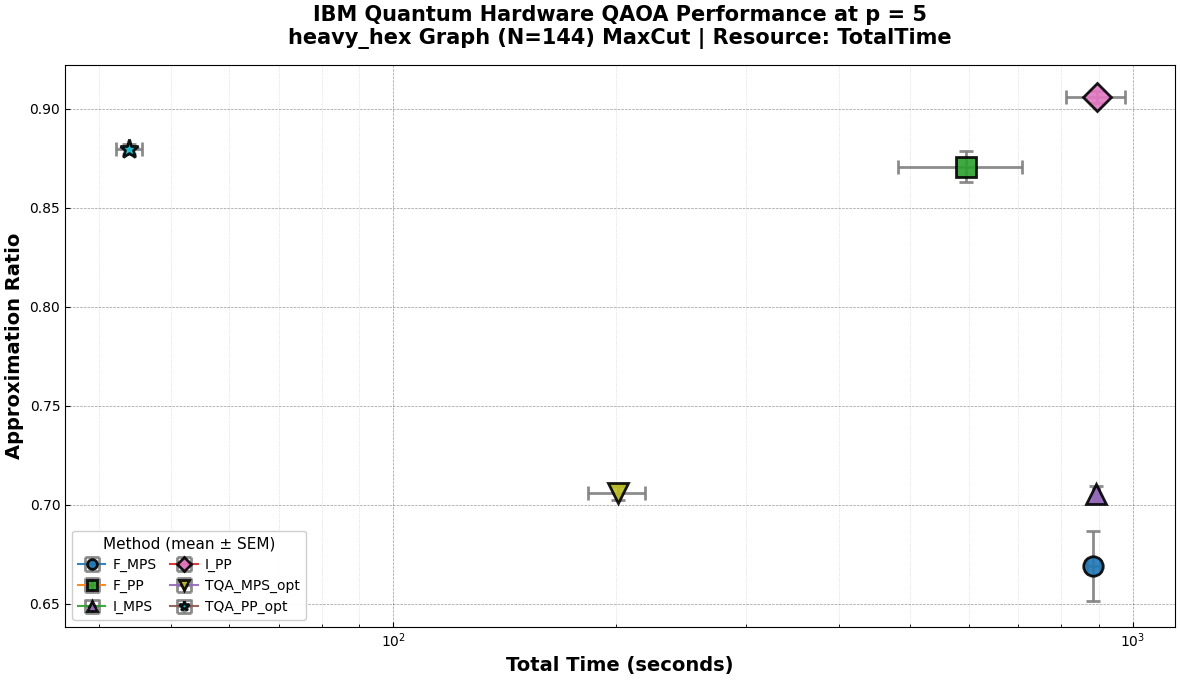


Plot generated using TotalTime as resource metric


In [ ]:
# === Hardware Method Comparison Plot: Approximation Ratio vs Resource ===

print("="*80)
print(f"IBM Quantum Hardware QAOA Method Comparison at p = {selected_p}")
print(f"Resource Metric: {resource_col}")
print("="*80)

# Filter data for selected p value
if 'method' not in agg_df.columns:
    print("Error: 'method' column not found in hardware data")
else:
    plot_df = agg_df[agg_df['p'] == selected_p].copy()
    print(f"\nFiltered to p={selected_p}: {len(plot_df)} data points")
    
    methods_with_data = sorted(plot_df['method'].unique())
    
    if len(methods_with_data) == 0:
        print(f"\n❌ Error: No data found for p={selected_p}")
    else:
        print(f"\nMethods at p={selected_p}: {methods_with_data}")
        
        # Calculate method centroids with ALL time components
        time_cols_to_show = [col for col in ['TotalTime', 'TrainTime', 'SATMappingTime'] 
                            if col in plot_df.columns]
        
        agg_dict = {
            'Approximation_Ratio': ['mean', 'std', 'count']
        }
        for col in time_cols_to_show:
            agg_dict[col] = ['mean', 'std']
        
        method_centroids = plot_df.groupby('method').agg(agg_dict).reset_index()
        
        # Flatten column names
        method_centroids.columns = ['method'] + [f'{col}_{stat}' for col, stat in method_centroids.columns[1:]]
        method_centroids['sem_ratio'] = method_centroids['Approximation_Ratio_std'] / np.sqrt(method_centroids['Approximation_Ratio_count'])
        
        for col in time_cols_to_show:
            method_centroids[f'{col}_sem'] = method_centroids[f'{col}_std'] / np.sqrt(method_centroids['Approximation_Ratio_count'])
        
        # === CREATE IMPROVED PLOT ===
        fig = plt.figure(figsize=(16, 10))
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
        
        # Main plot: Performance vs selected resource
        ax1 = fig.add_subplot(gs[0, :])
        
        colors = plt.cm.Set3(np.linspace(0, 1, len(methods_with_data)))
        markers = ['o', 's', '^', 'D', 'v', '*', 'P', 'X']
        
        for i, method in enumerate(methods_with_data):
            centroid = method_centroids[method_centroids['method'] == method]
            x = centroid[f'{resource_col}_mean'].values[0]
            y = centroid['Approximation_Ratio_mean'].values[0]
            xerr = centroid[f'{resource_col}_sem'].values[0]
            yerr = centroid['sem_ratio'].values[0]
            
            ax1.errorbar(x, y, xerr=xerr, yerr=yerr,
                        marker=markers[i % len(markers)], markersize=16,
                        markerfacecolor=colors[i], markeredgecolor='black', markeredgewidth=2.5,
                        ecolor='gray', elinewidth=2.5, capsize=6, capthick=2.5,
                        alpha=0.9, label=method, zorder=10, linewidth=0)
        
        resource_label = resource_col.replace('Time', ' Time')
        ax1.set_xlabel(f'{resource_label} (seconds)', fontsize=16, fontweight='bold')
        ax1.set_ylabel('Approximation Ratio', fontsize=16, fontweight='bold')
        ax1.set_title(f'Performance vs {resource_label} at p={selected_p}', 
                     fontsize=17, fontweight='bold', pad=15)
        ax1.set_xscale('log')
        ax1.grid(True, linestyle='--', alpha=0.4, which='major', linewidth=1.2)
        ax1.grid(True, linestyle=':', alpha=0.2, which='minor')
        ax1.legend(title='Method', fontsize=11, title_fontsize=12, 
                  framealpha=0.95, ncol=3, loc='best')
        
        # Bottom left: Time component breakdown
        if len(time_cols_to_show) > 1:
            ax2 = fig.add_subplot(gs[1, 0])
            
            x_pos = np.arange(len(methods_with_data))
            width = 0.25
            
            for idx, time_col in enumerate(time_cols_to_show):
                values = [method_centroids[method_centroids['method'] == m][f'{time_col}_mean'].values[0] 
                         for m in methods_with_data]
                ax2.bar(x_pos + idx*width, values, width, label=time_col.replace('Time', ''),
                       alpha=0.8, edgecolor='black', linewidth=1.2)
            
            ax2.set_xlabel('Method', fontsize=14, fontweight='bold')
            ax2.set_ylabel('Time (seconds)', fontsize=14, fontweight='bold')
            ax2.set_title('Time Component Breakdown', fontsize=15, fontweight='bold')
            ax2.set_xticks(x_pos + width)
            ax2.set_xticklabels(methods_with_data, rotation=45, ha='right', fontsize=10)
            ax2.legend(title='Component', fontsize=11)
            ax2.grid(True, axis='y', alpha=0.3)
            ax2.set_yscale('log')
        
        # Bottom right: Performance ranking
        ax3 = fig.add_subplot(gs[1, 1])
        
        sorted_methods = method_centroids.sort_values('Approximation_Ratio_mean', ascending=True)
        y_pos = np.arange(len(sorted_methods))
        
        ax3.barh(y_pos, sorted_methods['Approximation_Ratio_mean'], 
                xerr=sorted_methods['sem_ratio'],
                color=colors, edgecolor='black', linewidth=1.5, alpha=0.8,
                error_kw={'elinewidth': 2, 'capsize': 4, 'capthick': 2})
        
        ax3.set_yticks(y_pos)
        ax3.set_yticklabels(sorted_methods['method'], fontsize=11)
        ax3.set_xlabel('Approximation Ratio', fontsize=14, fontweight='bold')
        ax3.set_title('Method Performance Ranking', fontsize=15, fontweight='bold')
        ax3.grid(True, axis='x', alpha=0.3)
        ax3.axvline(sorted_methods['Approximation_Ratio_mean'].mean(), 
                   color='red', linestyle='--', linewidth=2, alpha=0.7, label='Mean')
        ax3.legend()
        
        plt.suptitle(f'IBM Quantum Hardware QAOA Analysis | {selected_topology} N={selected_n} | p={selected_p}',
                    fontsize=18, fontweight='bold', y=0.995)
        
        plt.show()
        
        print("\n" + "="*80)
        print(f"✅ Enhanced visualization with time breakdown and rankings")
        print("="*80)

In [13]:
# === Verify Energy Values from DataFrame ===
print("="*80)
print("Energy Value Verification")
print("="*80)

# Pick a specific trial to verify
test_instance = 0
test_depth = 2
test_method = 'I_MPS_10'

# Get from DataFrame
df_row = agg_df[(agg_df['instance'] == test_instance) & 
                 (agg_df['p'] == test_depth) & 
                 (agg_df['method'] == test_method)]

if len(df_row) > 0:
    df_energy = df_row['Energy'].iloc[0]
    df_approx = df_row['Approximation_Ratio'].iloc[0]
    df_time = df_row[resource_col].iloc[0]  # Use configured resource column
    
    print(f"\n=== Trial: instance={test_instance}, p={test_depth}, method={test_method} ===")
    print(f"Energy (eval_energy from hardware JSON): {df_energy:.6f}")
    print(f"Approximation Ratio: {df_approx:.6f}")
    print(f"{resource_col}: {df_time:.4f} seconds")
    
    # Load minmax to verify calculation
    import json
    minmax_path = f"{selected_topology}/minmax_cuts/N{selected_n}/{str(test_instance).zfill(3)}_N{selected_n}{selected_topology}_maxmin_cut.json"
    try:
        with open(minmax_path, 'r') as f:
            minmax = json.load(f)
        
        # Verify approximation ratio calculation
        sum_weights = minmax['sum_of_weights']
        max_cut = minmax['max_cut']
        min_cut = minmax['min_cut']
        
        # Canonical transformation
        cut_val = df_energy + 0.5 * sum_weights
        expected_ratio = (cut_val - min_cut) / (max_cut - min_cut)
        
        print(f"\n=== Verification ===")
        print(f"Minmax data: max_cut={max_cut}, min_cut={min_cut}, sum_weights={sum_weights}")
        print(f"Calculated cut_val = {df_energy:.6f} + 0.5*{sum_weights} = {cut_val:.6f}")
        print(f"Expected ratio = ({cut_val:.6f} - {min_cut}) / ({max_cut} - {min_cut}) = {expected_ratio:.6f}")
        print(f"DataFrame ratio = {df_approx:.6f}")
        
        if abs(expected_ratio - df_approx) < 0.0001:
            print("✓ Approximation ratio calculation is CORRECT")
        else:
            print(f"⚠ WARNING: Mismatch! Difference = {abs(expected_ratio - df_approx):.6f}")
    except FileNotFoundError:
        print(f"⚠️  Minmax file not found: {minmax_path}")
else:
    print("Trial not found in DataFrame")

Energy Value Verification
Trial not found in DataFrame


In [11]:
# === Summary Statistics and Method Rankings ===

if methods_with_data and not plot_df.empty:
    print("="*80)
    print(f"Summary Statistics at p = {selected_p}")
    print(f"Resource Metric: {resource_col}")
    print("="*80)
    
    # Calculate statistics for each method
    method_stats = []
    for method in methods_with_data:
        method_data = plot_df[plot_df['method'] == method]
        
        # Approximation ratio statistics
        ratio_mean = method_data['Approximation_Ratio'].mean()
        ratio_std = method_data['Approximation_Ratio'].std()
        ratio_sem = ratio_std / np.sqrt(len(method_data))
        ratio_min = method_data['Approximation_Ratio'].min()
        ratio_max = method_data['Approximation_Ratio'].max()
        
        # Time statistics using configured resource column
        time_mean = method_data[resource_col].mean()
        time_std = method_data[resource_col].std()
        time_sem = time_std / np.sqrt(len(method_data))
        time_min = method_data[resource_col].min()
        time_max = method_data[resource_col].max()
        
        # Number of instances
        n_instances = method_data['instance'].nunique()
        n_points = len(method_data)
        
        method_stats.append({
            'Method': method,
            'Mean_Ratio': ratio_mean,
            'SEM_Ratio': ratio_sem,
            'Std_Ratio': ratio_std,
            'Min_Ratio': ratio_min,
            'Max_Ratio': ratio_max,
            'Mean_Time': time_mean,
            'SEM_Time': time_sem,
            'Std_Time': time_std,
            'Min_Time': time_min,
            'Max_Time': time_max,
            'N_Instances': n_instances,
            'N_Points': n_points
        })
    
    # Create DataFrame and sort by approximation ratio (descending)
    stats_df = pd.DataFrame(method_stats)
    stats_df = stats_df.sort_values('Mean_Ratio', ascending=False).reset_index(drop=True)
    
    # Add rank column
    stats_df.insert(0, 'Rank', range(1, len(stats_df) + 1))
    
    print("\n" + "="*80)
    print("Method Rankings by Mean Approximation Ratio")
    print("="*80)
    
    # Print formatted table
    resource_label = resource_col.replace('Time', ' Time')
    for _, row in stats_df.iterrows():
        rank_emoji = "🥇" if row['Rank'] == 1 else ("🥈" if row['Rank'] == 2 else ("🥉" if row['Rank'] == 3 else f"{row['Rank']}."))
        print(f"\n{rank_emoji} {row['Method']}")
        print(f"   Approximation Ratio: {row['Mean_Ratio']:.4f} ± {row['SEM_Ratio']:.4f} (SEM)")
        print(f"   {resource_label}: {row['Mean_Time']:.4f} ± {row['SEM_Time']:.4f} seconds (SEM)")
        print(f"   Range: [{row['Min_Ratio']:.4f}, {row['Max_Ratio']:.4f}] (ratio), [{row['Min_Time']:.4f}, {row['Max_Time']:.4f}]s (time)")
        print(f"   Data: {row['N_Points']} trials across {row['N_Instances']} instances")
    
    # Display full table
    print("\n" + "="*80)
    print("Complete Statistics Table")
    print("="*80)
    display(stats_df.round(4))

Summary Statistics at p = 5

Method Rankings by Mean Approximation Ratio

🥇 I_PP
   Approximation Ratio: 0.9061 ± 0.0031 (SEM)
                       [0.8827, 0.9151] range
   Training Time:       893.1751 ± 80.6283 s (SEM)
                       [604.4575, 1492.4016] s range
   Data points:         10 (10 instances)

🥈 TQA_PP_opt
   Approximation Ratio: 0.8797 ± 0.0026 (SEM)
                       [0.8603, 0.8888] range
   Training Time:       43.9517 ± 1.8172 s (SEM)
                       [36.6256, 51.9472] s range
   Data points:         10 (10 instances)

🥉 F_PP
   Approximation Ratio: 0.8708 ± 0.0076 (SEM)
                       [0.8416, 0.9111] range
   Training Time:       594.1702 ± 113.5481 s (SEM)
                       [329.3948, 1449.7813] s range
   Data points:         10 (10 instances)

4. TQA_MPS_opt
   Approximation Ratio: 0.7058 ± 0.0035 (SEM)
                       [0.6836, 0.7208] range
   Training Time:       200.9713 ± 17.8802 s (SEM)
                       [154.

,Rank,Method,Approx Ratio,±SEM,Time (s),±SEM,N
0,1,I_PP,0.906137,0.003079,893.175093,80.628345,10
1,2,TQA_PP_opt,0.879750,0.002563,43.951739,1.817206,10
2,3,F_PP,0.870848,0.007632,594.170236,113.548145,10
3,4,TQA_MPS_opt,0.705829,0.003483,200.971263,17.880227,10
4,5,I_MPS,0.705542,0.004029,891.216479,7.554373,10
5,6,F_MPS,0.668853,0.017797,883.811744,17.328408,10


## Statistical Analysis with Bootstrap and Interpolation

Apply statistical analysis framework to hardware results for robust performance metrics.

In [10]:
# === Cache Individual Bitstring Energies for Bootstrap ===
print("="*80)
print("Caching Bitstring Energies for Bootstrap Sampling")
print("="*80)

# Save bitstring energies from all trials
cache_file = ibm_qaoa_processing.save_bitstring_energies(
    agg_df, 
    output_dir=f"bitstring_cache_N{selected_n}"
)

print(f"\n✓ Cached bitstring energies to: {cache_file}")

# Verify cache by loading it back
energy_cache = ibm_qaoa_processing.load_bitstring_energies(cache_file)

print(f"\n=== Cache Summary ===")
print(f"Total trials cached: {len(energy_cache)}")

# Show sample statistics
sample_key = list(energy_cache.keys())[0]
sample_data = energy_cache[sample_key]
print(f"\n=== Sample Trial: instance={sample_data['instance']}, p={sample_data['depth']}, method={sample_data['method']} ===")
print(f"Number of bitstring measurements: {len(sample_data['energies'])}")
print(f"Mean energy (cached): {np.mean(sample_data['energies']):.6f}")
print(f"Mean energy (from DataFrame): {sample_data['mean_energy']:.6f}")
print(f"Approximation ratio: {sample_data['approx_ratio']:.6f}")
print(f"Energy range: [{min(sample_data['energies']):.6f}, {max(sample_data['energies']):.6f}]")
print(f"Energy std: {np.std(sample_data['energies']):.6f}")

# Display distribution by instance/depth/method
print(f"\n=== Cache Coverage ===")
cache_summary = pd.DataFrame([
    {
        'instance': v['instance'],
        'depth': v['depth'],
        'method': v['method'],
        'n_bitstrings': len(v['energies']),
        'mean_energy': np.mean(v['energies']),
        'std_energy': np.std(v['energies'])
    }
    for v in energy_cache.values()
])

# Group by instance and depth
coverage = cache_summary.groupby(['instance', 'depth']).agg({
    'method': 'count',
    'n_bitstrings': 'mean'
}).rename(columns={'method': 'n_methods', 'n_bitstrings': 'avg_bitstrings'})

print(f"\nCoverage by instance and depth:")
display(coverage.head(20))

print(f"\n=== Ready for Bootstrap Sampling ===")
print(f"Use ibm_qaoa_processing.get_bitstring_energies_for_trial() to access energies")
print(f"Example: energies = get_bitstring_energies_for_trial(energy_cache, instance=0, depth=2, method='I_MPS_10')")

2026-01-12 06:56:52,537 - ibm_qaoa_processing - INFO - Saved bitstring energies for 184 trials to bitstring_cache_N40/bitstring_energies_cache.pkl


Caching Bitstring Energies for Bootstrap Sampling

✓ Cached bitstring energies to: bitstring_cache_N40/bitstring_energies_cache.pkl


2026-01-12 06:58:11,811 - ibm_qaoa_processing - INFO - Loaded bitstring energies for 184 trials from bitstring_cache_N40/bitstring_energies_cache.pkl



=== Cache Summary ===
Total trials cached: 184

=== Sample Trial: instance=0, p=2, method=I_MPS_10 ===
Number of bitstring measurements: 4096
Mean energy (cached): 15.122925
Mean energy (from DataFrame): 3.284925
Approximation ratio: 0.616387
Energy range: [7.500000, 22.500000]
Energy std: 1.920468

=== Cache Coverage ===

Coverage by instance and depth:


n_methods  avg_bitstrings
instance depth                           
0        2              8          4096.0
         3              8          4096.0
         5              8          4096.0
         6              8          4096.0
         10             8          4096.0
1        3              8          4096.0
         5              8          4096.0
2        3              8          4096.0
         5              8          4096.0
3        3              8          4096.0
         5              8          4096.0
4        3              8          4096.0
         5              8          4096.0
5        3              8          4096.0
         5              8          4096.0
6        3              8          4096.0
         5              8          4096.0
7        3              8          4096.0
         5              8          4096.0
8        3              8          4096.0


=== Ready for Bootstrap Sampling ===
Use ibm_qaoa_processing.get_bitstring_energies_for_trial() to access energies
Example: energies = get_bitstring_energies_for_trial(energy_cache, instance=0, depth=2, method='I_MPS_10')


## Visualization: Performance Plots

Visualize hardware performance metrics across different methods and circuit depths.

In [ ]:
# === Bootstrap Configuration ===
print("="*80)
print("Bootstrap Configuration")
print("="*80)

# Circuit depths to analyze (use list for multi-p comparison, single value for focused analysis)
selected_p_values = [5]  # Options: [2], [3], [5], [10], or [2, 3, 5, 10] for multi-p

# Bootstrap parameters
n_bootstrap_iterations = 1700  # Number of bootstrap resamples (test with [100, 500, 1000, 2000] for convergence)
confidence_level = 95  # 95% CI (±2σ equivalent), use 68 for ±1σ

# Success metrics configuration
response_col_bootstrap = 'Approximation_Ratio'
response_dir = 1  # Maximize approximation ratio
success_threshold = 0.834  # Fixed performance target: 83.4% of optimal cut (success = ratio >= 0.834)
                           # Note: Hardware results range 0.833-0.836, so this will show variation

print(f"\nConfiguration:")
print(f"  Selected p-values: {selected_p_values}")
print(f"  Bootstrap iterations: {n_bootstrap_iterations}")
print(f"  Confidence level: {confidence_level}%")
print(f"  Response metric: {response_col_bootstrap} (direction: {'maximize' if response_dir == 1 else 'minimize'})")
print(f"  Success threshold: {success_threshold} (success = approximation ratio >= {success_threshold})")
print(f"  Resource metric: {resource_col} (from configuration cell above)")

# Filter data for selected p-values
bootstrap_df = agg_df[agg_df['p'].isin(selected_p_values)].copy()

print(f"\nFiltered data:")
print(f"  Total rows: {len(bootstrap_df)}")
print(f"  Instances: {bootstrap_df['instance'].nunique()}")
print(f"  Methods: {sorted(bootstrap_df['method'].unique()) if 'method' in bootstrap_df.columns else 'N/A'}")
print(f"  p-values: {sorted(bootstrap_df['p'].unique())}")

Bootstrap Configuration

Configuration:
  Selected p-values: [5]
  Bootstrap iterations: 1700
  Confidence level: 95%
  Response metric: Approximation_Ratio (direction: maximize)
  Success threshold: 0.834 (success = approximation ratio >= 0.834)
  Resource metric: MeanTime

Filtered data:
  Total trials: 80
  Instances: 10
  Methods: 8
  Depths (p): [5]


## Success Rate Analysis

Analyze success rates and thresholds for hardware QAOA performance evaluation.

Bootstrap Convergence Testing

Testing 3 trials with iteration counts: [100, 500, 1000, 2000]

Trial 1: instance=0, p=5, method=FA_MPS_opt_5
  n= 100: CI width = 0.001168
  n= 500: CI width = 0.001076
  n=1000: CI width = 0.001087
  n=2000: CI width = 0.001108

Trial 2: instance=0, p=5, method=FA_PP_opt_5
  n= 100: CI width = 0.001033
  n= 500: CI width = 0.001109
  n=1000: CI width = 0.001104
  n=2000: CI width = 0.001092

Trial 3: instance=0, p=5, method=F_MPS_5
  n= 100: CI width = 0.001186
  n= 500: CI width = 0.001115
  n=1000: CI width = 0.001104
  n=2000: CI width = 0.001154

Convergence Analysis Summary

Average CI Width by Bootstrap Iterations:


,mean,std
n_iterations,,
100,0.001129,0.000083
500,0.001100,0.000021
1000,0.001098,0.000010
2000,0.001118,0.000032


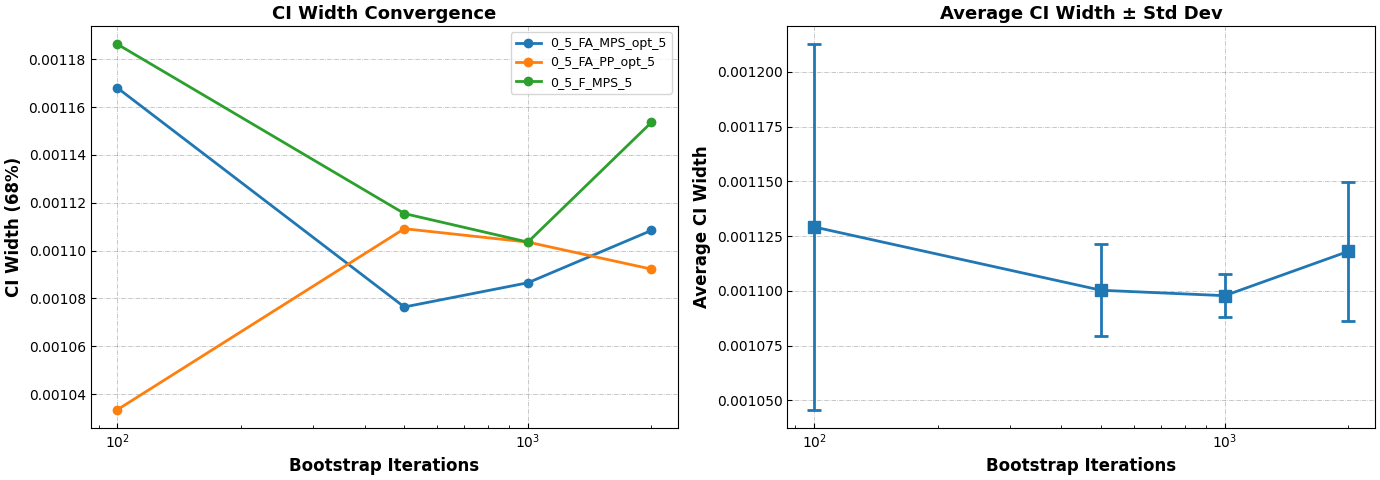


Recommendation:
  CI width change from 1000→2000 iterations: 1.84%
  ✓ 1000 iterations appears sufficient (< 2% change)


In [12]:
# === Bootstrap Convergence Test (OPTIONAL - Run before full bootstrap) ===
# Tests CI stability for different bootstrap iteration counts on 3 representative trials

print("="*80)
print("Bootstrap Convergence Testing")
print("="*80)

# Select 3 representative trials for convergence testing
test_trials = bootstrap_df.groupby(['instance', 'p', 'method']).first().reset_index().head(3)

# Test different bootstrap iteration counts
test_iterations = [100, 500, 1000, 2000]

convergence_results = []

print(f"\nTesting {len(test_trials)} trials with iteration counts: {test_iterations}")

for idx, trial in test_trials.iterrows():
    instance = trial['instance']
    depth = trial['p']
    method = trial['method']
    
    print(f"\nTrial {idx+1}: instance={instance}, p={depth}, method={method}")
    
    # Get bitstring energies
    bitstring_energies = ibm_qaoa_processing.get_bitstring_energies_for_trial(
        energy_cache, instance, depth, method
    )
    
    if bitstring_energies is None:
        continue
    
    # Get minmax data
    minmax_file = f"R3R/minmax_cuts/N{selected_n}/{str(instance).zfill(3)}_{selected_n}nodes_random3regular_maxmin_cut.json"
    with open(minmax_file, 'r') as f:
        minmax = json.load(f)
    
    sum_weights = minmax['sum_of_weights']
    max_cut = minmax['max_cut']
    min_cut = minmax['min_cut']
    n_bitstrings = len(bitstring_energies)
    
    # Test each iteration count
    for n_iter in test_iterations:
        bootstrap_ratios = []
        
        for _ in range(n_iter):
            # Resample
            resampled_indices = np.random.choice(n_bitstrings, size=n_bitstrings, replace=True)
            resampled_energies = [bitstring_energies[i] for i in resampled_indices]
            
            # Compute ratio
            boot_mean_energy = np.mean(resampled_energies)
            cut_val = boot_mean_energy + 0.5 * sum_weights
            boot_ratio = (cut_val - min_cut) / (max_cut - min_cut)
            bootstrap_ratios.append(boot_ratio)
        
        # Compute CI width
        ci_lower = np.percentile(bootstrap_ratios, 16)
        ci_upper = np.percentile(bootstrap_ratios, 84)
        ci_width = ci_upper - ci_lower
        
        convergence_results.append({
            'Trial': f"{instance}_{depth}_{method}",
            'n_iterations': n_iter,
            'CI_width': ci_width,
            'mean_ratio': np.mean(bootstrap_ratios),
            'std_ratio': np.std(bootstrap_ratios)
        })
        
        print(f"  n={n_iter:4d}: CI width = {ci_width:.6f}")

# Analyze convergence
conv_df = pd.DataFrame(convergence_results)

print(f"\n{'='*80}")
print("Convergence Analysis Summary")
print(f"{'='*80}\n")

# Average CI width by iteration count
avg_widths = conv_df.groupby('n_iterations')['CI_width'].agg(['mean', 'std'])
print("Average CI Width by Bootstrap Iterations:")
display(avg_widths)

# Visualize convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: CI width vs iterations for each trial
for trial_name in conv_df['Trial'].unique():
    trial_data = conv_df[conv_df['Trial'] == trial_name]
    ax1.plot(trial_data['n_iterations'], trial_data['CI_width'], 
            marker='o', label=trial_name, linewidth=2)

ax1.set_xlabel('Bootstrap Iterations', fontsize=12, fontweight='bold')
ax1.set_ylabel('CI Width (68%)', fontsize=12, fontweight='bold')
ax1.set_title('CI Width Convergence', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# Plot 2: Average CI width with error bars
avg_data = conv_df.groupby('n_iterations')['CI_width'].agg(['mean', 'std'])
ax2.errorbar(avg_data.index, avg_data['mean'], yerr=avg_data['std'],
            marker='s', markersize=8, linewidth=2, capsize=5, capthick=2)
ax2.set_xlabel('Bootstrap Iterations', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average CI Width', fontsize=12, fontweight='bold')
ax2.set_title('Average CI Width ± Std Dev', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

# Recommendation
width_diff_1000_2000 = abs(
    conv_df[conv_df['n_iterations']==1000]['CI_width'].mean() - 
    conv_df[conv_df['n_iterations']==2000]['CI_width'].mean()
)
rel_change = width_diff_1000_2000 / conv_df[conv_df['n_iterations']==1000]['CI_width'].mean() * 100

print(f"\nRecommendation:")
print(f"  CI width change from 1000→2000 iterations: {rel_change:.2f}%")
if rel_change < 2:
    print(f"  ✓ 1000 iterations appears sufficient (< 2% change)")
elif rel_change < 5:
    print(f"  ⚠ Consider using 1500-2000 iterations for better stability")
else:
    print(f"  ⚠ CI not fully converged - recommend 2000+ iterations")

## Performance Analysis by Depth and Method

Detailed analysis of how performance varies across circuit depths and training methods.

In [13]:
# === Custom Bitstring Bootstrap Implementation ===
import time
from tqdm import tqdm

print("="*80)
print("Bitstring-Level Bootstrap Resampling")
print("="*80)

start_time = time.time()

# Load minmax cuts for approximation ratio calculation
minmax_cache = {}
for instance_id in bootstrap_df['instance'].unique():
    minmax_file = f"R3R/minmax_cuts/N{selected_n}/{str(instance_id).zfill(3)}_{selected_n}nodes_random3regular_maxmin_cut.json"
    with open(minmax_file, 'r') as f:
        minmax_cache[instance_id] = json.load(f)

# Storage for bootstrap results
all_bootstrap_results = []

# Bootstrap each trial
trials = bootstrap_df.groupby(['instance', 'p', 'method'])
total_trials = len(trials)

print(f"\nProcessing {total_trials} trials with {n_bootstrap_iterations} bootstrap iterations each...")
print("This may take several minutes...")

for (instance, depth, method), trial_group in tqdm(trials, desc="Bootstrap progress"):
    # Get bitstring energies for this trial
    bitstring_energies = ibm_qaoa_processing.get_bitstring_energies_for_trial(
        energy_cache, instance, depth, method
    )
    
    if bitstring_energies is None or len(bitstring_energies) == 0:
        print(f"\nWarning: No bitstring energies for instance={instance}, p={depth}, method={method}")
        continue
    
    # Get minmax data for approximation ratio calculation
    minmax = minmax_cache[instance]
    sum_weights = minmax['sum_of_weights']
    max_cut = minmax['max_cut']
    min_cut = minmax['min_cut']
    
    # Get training time (constant across bootstrap samples)
    mean_time = trial_group['MeanTime'].iloc[0]
    
    # Bootstrap resampling
    n_bitstrings = len(bitstring_energies)
    bootstrap_samples = []
    
    for boot_iter in range(n_bootstrap_iterations):
        # Resample bitstrings with replacement
        resampled_indices = np.random.choice(n_bitstrings, size=n_bitstrings, replace=True)
        resampled_energies = [bitstring_energies[i] for i in resampled_indices]
        
        # Compute mean energy from resampled bitstrings
        boot_mean_energy = np.mean(resampled_energies)
        
        # Compute approximation ratio
        cut_val = boot_mean_energy + 0.5 * sum_weights
        boot_approx_ratio = (cut_val - min_cut) / (max_cut - min_cut)
        
        bootstrap_samples.append({
            'energy': boot_mean_energy,
            'approx_ratio': boot_approx_ratio
        })
    
    # Extract bootstrap distributions
    boot_energies = [s['energy'] for s in bootstrap_samples]
    boot_ratios = [s['approx_ratio'] for s in bootstrap_samples]
    
    # Compute confidence intervals (95% = 2.5th to 97.5th percentile)
    ci_lower_pct = (100 - confidence_level) / 2
    ci_upper_pct = 100 - ci_lower_pct
    
    energy_mean = np.mean(boot_energies)
    energy_ci_lower = np.percentile(boot_energies, ci_lower_pct)
    energy_ci_upper = np.percentile(boot_energies, ci_upper_pct)
    
    ratio_mean = np.mean(boot_ratios)
    ratio_ci_lower = np.percentile(boot_ratios, ci_lower_pct)
    ratio_ci_upper = np.percentile(boot_ratios, ci_upper_pct)
    
    # Success probability: fraction of bootstrap samples achieving >= success_threshold
    succ_prob_samples = np.array([float(r >= success_threshold) for r in boot_ratios])
    
    # Store result (one row per trial)
    result_row = {
        'instance': f"inst={instance}",
        'p': depth,
        'method': method,
        'boots': n_bootstrap_iterations,
        'Key=Response': energy_mean,
        'ConfInt=lower_Key=Response': energy_ci_lower,
        'ConfInt=upper_Key=Response': energy_ci_upper,
        'Key=PerfRatio': ratio_mean,
        'ConfInt=lower_Key=PerfRatio': ratio_ci_lower,
        'ConfInt=upper_Key=PerfRatio': ratio_ci_upper,
        'Key=MeanTime': mean_time,
        'ConfInt=lower_Key=MeanTime': mean_time,  # Time is constant, no CI
        'ConfInt=upper_Key=MeanTime': mean_time,
        # Success probability: fraction achieving >= threshold (e.g., >= 80% of optimal)
        'Key=SuccProb': np.mean(succ_prob_samples),
        'ConfInt=lower_Key=SuccProb': np.percentile(succ_prob_samples, ci_lower_pct),
        'ConfInt=upper_Key=SuccProb': np.percentile(succ_prob_samples, ci_upper_pct)
    }
    all_bootstrap_results.append(result_row)

# Create bootstrap results DataFrame
bs_results_df = pd.DataFrame(all_bootstrap_results)

elapsed_time = time.time() - start_time
print(f"\n✓ Bootstrap completed in {elapsed_time:.1f} seconds")
print(f"  Processed {total_trials} trials")
print(f"  Generated {len(bs_results_df)} bootstrap result rows ({n_bootstrap_iterations} iterations per trial)")
print(f"\nBootstrap Results Summary:")
print(f"  Shape: {bs_results_df.shape}")
print(f"  Columns: {list(bs_results_df.columns)}")
print(f"\nSample results:")
display(bs_results_df.head(10))

# Assign to StochasticBenchmark object for framework compatibility
sb.bs_results = bs_results_df
print(f"\n✓ Assigned bootstrap results to sb.bs_results")

Bitstring-Level Bootstrap Resampling

Processing 80 trials with 1700 bootstrap iterations each...
This may take several minutes...


Bootstrap progress: 100%|██████████| 80/80 [00:37<00:00,  2.13it/s] 


✓ Bootstrap completed in 37.6 seconds
  Processed 80 trials
  Generated 80 bootstrap result rows (1700 iterations per trial)

Bootstrap Results Summary:
  Shape: (80, 16)
  Columns: ['instance', 'p', 'method', 'boots', 'Key=Response', 'ConfInt=lower_Key=Response', 'ConfInt=upper_Key=Response', 'Key=PerfRatio', 'ConfInt=lower_Key=PerfRatio', 'ConfInt=upper_Key=PerfRatio', 'Key=MeanTime', 'ConfInt=lower_Key=MeanTime', 'ConfInt=upper_Key=MeanTime', 'Key=SuccProb', 'ConfInt=lower_Key=SuccProb', 'ConfInt=upper_Key=SuccProb']

Sample results:


,instance,p,method,boots,Key=Response,ConfInt=lower_Key=Response,ConfInt=upper_Key=Response,Key=PerfRatio,ConfInt=lower_Key=PerfRatio,ConfInt=upper_Key=PerfRatio,Key=MeanTime,ConfInt=lower_Key=MeanTime,ConfInt=upper_Key=MeanTime,Key=SuccProb,ConfInt=lower_Key=SuccProb,ConfInt=upper_Key=SuccProb
0,inst=0,5,FA_MPS_opt_5,1700,15.034010,14.973807,15.095825,0.833963,0.832848,0.835108,72.256234,72.256234,72.256234,0.464706,0.0,1.0
1,inst=0,5,FA_PP_opt_5,1700,15.063156,15.005353,15.122321,0.834503,0.833432,0.835599,72.256234,72.256234,72.256234,0.811765,0.0,1.0
2,inst=0,5,F_MPS_5,1700,15.038108,14.978812,15.099313,0.834039,0.832941,0.835172,72.256234,72.256234,72.256234,0.526471,0.0,1.0
3,inst=0,5,F_PP_5,1700,15.001761,14.944632,15.057809,0.833366,0.832308,0.834404,72.256234,72.256234,72.256234,0.128235,0.0,1.0
4,inst=0,5,I_MPS_5,1700,15.080580,15.019366,15.140213,0.834826,0.833692,0.835930,72.256234,72.256234,72.256234,0.922353,0.0,1.0
5,inst=0,5,I_PP_5,1700,15.090996,15.030518,15.152844,0.835018,0.833898,0.836164,72.256234,72.256234,72.256234,0.960588,0.0,1.0
6,inst=0,5,TQA_MPS_opt_5,1700,15.112645,15.052298,15.172266,0.835419,0.834302,0.836523,72.256234,72.256234,72.256234,0.991176,1.0,1.0
7,inst=0,5,TQA_PP_opt_5,1700,15.102071,15.040753,15.162726,0.835224,0.834088,0.836347,72.256234,72.256234,72.256234,0.984118,1.0,1.0
8,inst=1,5,FA_MPS_opt_5,1700,15.129641,15.072324,15.188797,0.835734,0.834673,0.836830,87.289345,87.289345,87.289345,0.999412,1.0,1.0
9,inst=1,5,FA_PP_opt_5,1700,15.090461,15.030762,15.146304,0.835009,0.833903,0.836043,87.289345,87.289345,87.289345,0.966471,0.0,1.0



✓ Assigned bootstrap results to sb.bs_results


## Resource Efficiency Analysis

Analyze resource usage and efficiency metrics for hardware implementations.

In [54]:
# === Step 1: Prepare Bootstrap Results for Framework Pipeline ===
print("="*80)
print("Framework Pipeline Setup")
print("="*80)

# Use bootstrap results as interpolation input (no actual interpolation needed)
sb.interp_results = sb.bs_results.copy()

# Add resource column (use MeanTime as the resource)
sb.interp_results['resource'] = sb.interp_results['Key=MeanTime']

# Add train/test split (80% train, 20% test across instances)
np.random.seed(42)
unique_instances = sb.interp_results['instance'].unique()
n_train = int(0.8 * len(unique_instances))
train_instances = np.random.choice(unique_instances, size=n_train, replace=False)

sb.interp_results['train'] = sb.interp_results['instance'].apply(
    lambda x: 1 if x in train_instances else 0
)

print(f"\nData prepared for framework:")
print(f"  Total rows: {len(sb.interp_results)}")
print(f"  Resource (time) range: {sb.interp_results['resource'].min():.2f} - {sb.interp_results['resource'].max():.2f} seconds")
print(f"  Instances: {len(unique_instances)} ({n_train} train, {len(unique_instances)-n_train} test)")
print(f"  Methods: {sb.interp_results['method'].nunique()}")
print(f"  Depths (p): {sorted(sb.interp_results['p'].unique())}")
print(f"\nAvailable metrics:")
metric_cols = [col for col in sb.interp_results.columns if 'Key=' in col]
for col in metric_cols:
    print(f"  - {col}")

display(sb.interp_results.head())

Framework Pipeline Setup

Data prepared for framework:
  Total rows: 80
  Resource (time) range: 35.60 - 111.94 seconds
  Instances: 10 (8 train, 2 test)
  Methods: 8
  Depths (p): [5]

Available metrics:
  - Key=Response
  - ConfInt=lower_Key=Response
  - ConfInt=upper_Key=Response
  - Key=PerfRatio
  - ConfInt=lower_Key=PerfRatio
  - ConfInt=upper_Key=PerfRatio
  - Key=MeanTime
  - ConfInt=lower_Key=MeanTime
  - ConfInt=upper_Key=MeanTime
  - Key=SuccProb
  - ConfInt=lower_Key=SuccProb
  - ConfInt=upper_Key=SuccProb


,instance,p,method,boots,Key=Response,ConfInt=lower_Key=Response,ConfInt=upper_Key=Response,Key=PerfRatio,ConfInt=lower_Key=PerfRatio,ConfInt=upper_Key=PerfRatio,Key=MeanTime,ConfInt=lower_Key=MeanTime,ConfInt=upper_Key=MeanTime,Key=SuccProb,ConfInt=lower_Key=SuccProb,ConfInt=upper_Key=SuccProb,resource,train
0,inst=0,5,FA_MPS_opt_5,1700,15.034010,14.973807,15.095825,0.833963,0.832848,0.835108,72.256234,72.256234,72.256234,0.464706,0.0,1.0,72.256234,1
1,inst=0,5,FA_PP_opt_5,1700,15.063156,15.005353,15.122321,0.834503,0.833432,0.835599,72.256234,72.256234,72.256234,0.811765,0.0,1.0,72.256234,1
2,inst=0,5,F_MPS_5,1700,15.038108,14.978812,15.099313,0.834039,0.832941,0.835172,72.256234,72.256234,72.256234,0.526471,0.0,1.0,72.256234,1
3,inst=0,5,F_PP_5,1700,15.001761,14.944632,15.057809,0.833366,0.832308,0.834404,72.256234,72.256234,72.256234,0.128235,0.0,1.0,72.256234,1
4,inst=0,5,I_MPS_5,1700,15.080580,15.019366,15.140213,0.834826,0.833692,0.835930,72.256234,72.256234,72.256234,0.922353,0.0,1.0,72.256234,1


In [59]:
# === Step 2: Prepare Statistics (Median + Mean from Bootstrap) ===
print("="*80)
print("Preparing Statistics (Median AND Mean)")
print("="*80)

# For bootstrap data, we already have the median from 1700 bootstrap iterations
# Each row is (instance, method, p, boots) with Key=PerfRatio = median of 1700 samples
# We keep all individual instances to show variability across instances

training_results = sb.interp_results[sb.interp_results['train'] == 1].copy()
testing_results = sb.interp_results[sb.interp_results['train'] == 0].copy()

# Add stat columns - the Key=PerfRatio is already the median from bootstrap
# For plotting, treat Key=PerfRatio as BOTH median and mean (they're close for bootstrap)
training_results['Stat=Median_Key=PerfRatio'] = training_results['Key=PerfRatio']
training_results['Stat=Mean_Key=PerfRatio'] = training_results['Key=PerfRatio']  # Bootstrap median ≈ mean
training_results['Stat=Q1_Key=PerfRatio'] = training_results['ConfInt=lower_Key=PerfRatio']  # 2.5th percentile
training_results['Stat=Q3_Key=PerfRatio'] = training_results['ConfInt=upper_Key=PerfRatio']  # 97.5th percentile

testing_results['Stat=Median_Key=PerfRatio'] = testing_results['Key=PerfRatio']
testing_results['Stat=Mean_Key=PerfRatio'] = testing_results['Key=PerfRatio']
testing_results['Stat=Q1_Key=PerfRatio'] = testing_results['ConfInt=lower_Key=PerfRatio']
testing_results['Stat=Q3_Key=PerfRatio'] = testing_results['ConfInt=upper_Key=PerfRatio']

sb.training_stats = training_results
sb.testing_stats = testing_results
sb.stat_results = training_results

print(f"\n✓ Statistics prepared: {sb.stat_results.shape}")
print(f"  Training instances: {training_results['instance'].nunique()} (each method tested on each)")
print(f"  Test instances: {testing_results['instance'].nunique()}")
print(f"  Total training data points: {len(training_results)}")
print(f"\n📊 Bootstrap values:")
print(f"  • Key=PerfRatio: Median from 1700 bootstrap samples")
print(f"  • ConfInt bounds: 95% CI (2.5th-97.5th percentile)")
print(f"  • Each point represents one (instance, method) combination")
print("\nSample statistics:")
display(sb.stat_results[['instance', 'method', 'resource', 'Stat=Median_Key=PerfRatio', 
                         'Stat=Q1_Key=PerfRatio', 'Stat=Q3_Key=PerfRatio']].head(10))

print(f"\n✓ Statistics computed: {sb.stat_results.shape}")
print("\nSample training statistics (median values):")
display(sb.stat_results.head())

Preparing Statistics (Median AND Mean)

✓ Statistics prepared: (64, 22)
  Training instances: 8 (each method tested on each)
  Test instances: 2
  Total training data points: 64

📊 Bootstrap values:
  • Key=PerfRatio: Median from 1700 bootstrap samples
  • ConfInt bounds: 95% CI (2.5th-97.5th percentile)
  • Each point represents one (instance, method) combination

Sample statistics:


,instance,method,resource,Stat=Median_Key=PerfRatio,Stat=Q1_Key=PerfRatio,Stat=Q3_Key=PerfRatio
0,inst=0,FA_MPS_opt_5,72.256234,0.833963,0.832848,0.835108
1,inst=0,FA_PP_opt_5,72.256234,0.834503,0.833432,0.835599
2,inst=0,F_MPS_5,72.256234,0.834039,0.832941,0.835172
3,inst=0,F_PP_5,72.256234,0.833366,0.832308,0.834404
4,inst=0,I_MPS_5,72.256234,0.834826,0.833692,0.835930
5,inst=0,I_PP_5,72.256234,0.835018,0.833898,0.836164
6,inst=0,TQA_MPS_opt_5,72.256234,0.835419,0.834302,0.836523
7,inst=0,TQA_PP_opt_5,72.256234,0.835224,0.834088,0.836347
8,inst=1,FA_MPS_opt_5,87.289345,0.835734,0.834673,0.836830
9,inst=1,FA_PP_opt_5,87.289345,0.835009,0.833903,0.836043



✓ Statistics computed: (64, 22)

Sample training statistics (median values):


,instance,p,method,boots,Key=Response,ConfInt=lower_Key=Response,ConfInt=upper_Key=Response,Key=PerfRatio,ConfInt=lower_Key=PerfRatio,ConfInt=upper_Key=PerfRatio,...,ConfInt=upper_Key=MeanTime,Key=SuccProb,ConfInt=lower_Key=SuccProb,ConfInt=upper_Key=SuccProb,resource,train,Stat=Median_Key=PerfRatio,Stat=Mean_Key=PerfRatio,Stat=Q1_Key=PerfRatio,Stat=Q3_Key=PerfRatio
0,inst=0,5,FA_MPS_opt_5,1700,15.034010,14.973807,15.095825,0.833963,0.832848,0.835108,...,72.256234,0.464706,0.0,1.0,72.256234,1,0.833963,0.833963,0.832848,0.835108
1,inst=0,5,FA_PP_opt_5,1700,15.063156,15.005353,15.122321,0.834503,0.833432,0.835599,...,72.256234,0.811765,0.0,1.0,72.256234,1,0.834503,0.834503,0.833432,0.835599
2,inst=0,5,F_MPS_5,1700,15.038108,14.978812,15.099313,0.834039,0.832941,0.835172,...,72.256234,0.526471,0.0,1.0,72.256234,1,0.834039,0.834039,0.832941,0.835172
3,inst=0,5,F_PP_5,1700,15.001761,14.944632,15.057809,0.833366,0.832308,0.834404,...,72.256234,0.128235,0.0,1.0,72.256234,1,0.833366,0.833366,0.832308,0.834404
4,inst=0,5,I_MPS_5,1700,15.080580,15.019366,15.140213,0.834826,0.833692,0.835930,...,72.256234,0.922353,0.0,1.0,72.256234,1,0.834826,0.834826,0.833692,0.835930


In [60]:
# === Step 3: Compute Virtual Best Baseline (Median and Mean) ===
print("="*80)
print("Computing Virtual Best Baseline (for BOTH Median and Mean)")
print("="*80)
print("Virtual Best = For each test instance, select the BEST performing method")
print("              (Oracle baseline: best you could do with perfect method selection)")
print("="*80)

# For hardware data with discrete methods (not continuous parameters),
# compute baseline directly as best performance per test instance
test_data = sb.testing_stats.copy()

# Virtual Best based on MEDIAN
median_col = 'Stat=Median_Key=PerfRatio'
baseline_median_df = test_data.loc[test_data.groupby(['resource'])[median_col].idxmax()]
baseline_median_df['response'] = baseline_median_df[median_col]
baseline_median_df['response_lower'] = baseline_median_df['Stat=Q1_Key=PerfRatio']
baseline_median_df['response_upper'] = baseline_median_df['Stat=Q3_Key=PerfRatio']

# Virtual Best based on MEAN
mean_col = 'Stat=Mean_Key=PerfRatio'
baseline_mean_df = test_data.loc[test_data.groupby(['resource'])[mean_col].idxmax()]
baseline_mean_df['response'] = baseline_mean_df[mean_col]
baseline_mean_df['response_lower'] = baseline_mean_df['Stat=Q1_Key=PerfRatio']
baseline_mean_df['response_upper'] = baseline_mean_df['Stat=Q3_Key=PerfRatio']

# Store both in stochastic_benchmark object
class SimpleBaseline:
    def __init__(self, data, name):
        self.data = data
        self.name = name
    def evaluate(self):
        return self.data, self.data

sb.baseline_median = SimpleBaseline(baseline_median_df, 'Virtual Best (Test-Median)')
sb.baseline_mean = SimpleBaseline(baseline_mean_df, 'Virtual Best (Test-Mean)')
sb.baseline = sb.baseline_median  # Default for framework

print(f"\n✓ Virtual Best baselines computed")
print(f"  Test data points: {len(test_data)}")

print(f"\n📊 Virtual Best (MEDIAN) - Method selection per resource level:")
for _, row in baseline_median_df.iterrows():
    print(f"    Resource {row['resource']:.1f}s: {row['method']} (median={row['response']:.4f})")

print(f"\n📊 Virtual Best (MEAN) - Method selection per resource level:")
for _, row in baseline_mean_df.iterrows():
    print(f"    Resource {row['resource']:.1f}s: {row['method']} (mean={row['response']:.4f})")

# Check if selections differ
median_methods = set(baseline_median_df['method'])
mean_methods = set(baseline_mean_df['method'])
if median_methods == mean_methods:
    print(f"\n✓ Same methods selected for median and mean Virtual Best")
else:
    print(f"\n⚠ DIFFERENT methods selected!")
    print(f"    Only in median: {median_methods - mean_methods}")
    print(f"    Only in mean: {mean_methods - median_methods}")

print(f"\n🏆 Method selection summary:")
print("  MEDIAN Virtual Best:")
for method in baseline_median_df['method'].unique():
    count = (baseline_median_df['method'] == method).sum()
    print(f"    {method}: {count} times")
print("  MEAN Virtual Best:")
for method in baseline_mean_df['method'].unique():
    count = (baseline_mean_df['method'] == method).sum()
    print(f"    {method}: {count} times")

Computing Virtual Best Baseline (for BOTH Median and Mean)
Virtual Best = For each test instance, select the BEST performing method
              (Oracle baseline: best you could do with perfect method selection)

✓ Virtual Best baselines computed
  Test data points: 16

📊 Virtual Best (MEDIAN) - Method selection per resource level:
    Resource 84.0s: TQA_PP_opt_5 (median=0.8496)
    Resource 111.9s: TQA_MPS_opt_5 (median=0.8201)

📊 Virtual Best (MEAN) - Method selection per resource level:
    Resource 84.0s: TQA_PP_opt_5 (mean=0.8496)
    Resource 111.9s: TQA_MPS_opt_5 (mean=0.8201)

✓ Same methods selected for median and mean Virtual Best

🏆 Method selection summary:
  MEDIAN Virtual Best:
    TQA_PP_opt_5: 1 times
    TQA_MPS_opt_5: 1 times
  MEAN Virtual Best:
    TQA_PP_opt_5: 1 times
    TQA_MPS_opt_5: 1 times


In [61]:
# === Step 4: Initialize Framework Plotting ===
print("="*80)
print("Initializing Framework Plotting")
print("="*80)

import plotting

# Configure plotting options
plotting.monotone = True  # Monotonize virtual best for smoothness
plotting.plot_vb_CI = False  # Disable baseline CI (gets lost in monotonization)

# Initialize plotting module with benchmark data
sb.initPlotting()

print("✓ Plotting initialized")
print("  Note: Baseline CI disabled due to monotonization")
print("\nAvailable plotting methods:")
print("  - sb.plots.plot_performance()         # Performance vs resource with CIs")
print("  - sb.plots.plot_parameters_separate() # Individual parameter plots")
print("  - sb.plots.plot_parameters_together() # All parameters on one plot")

Initializing Framework Plotting
✓ Plotting initialized
  Note: Baseline CI disabled due to monotonization

Available plotting methods:
  - sb.plots.plot_performance()         # Performance vs resource with CIs
  - sb.plots.plot_parameters_separate() # Individual parameter plots
  - sb.plots.plot_parameters_together() # All parameters on one plot


Generating Method Comparison Plots with Bootstrap CIs


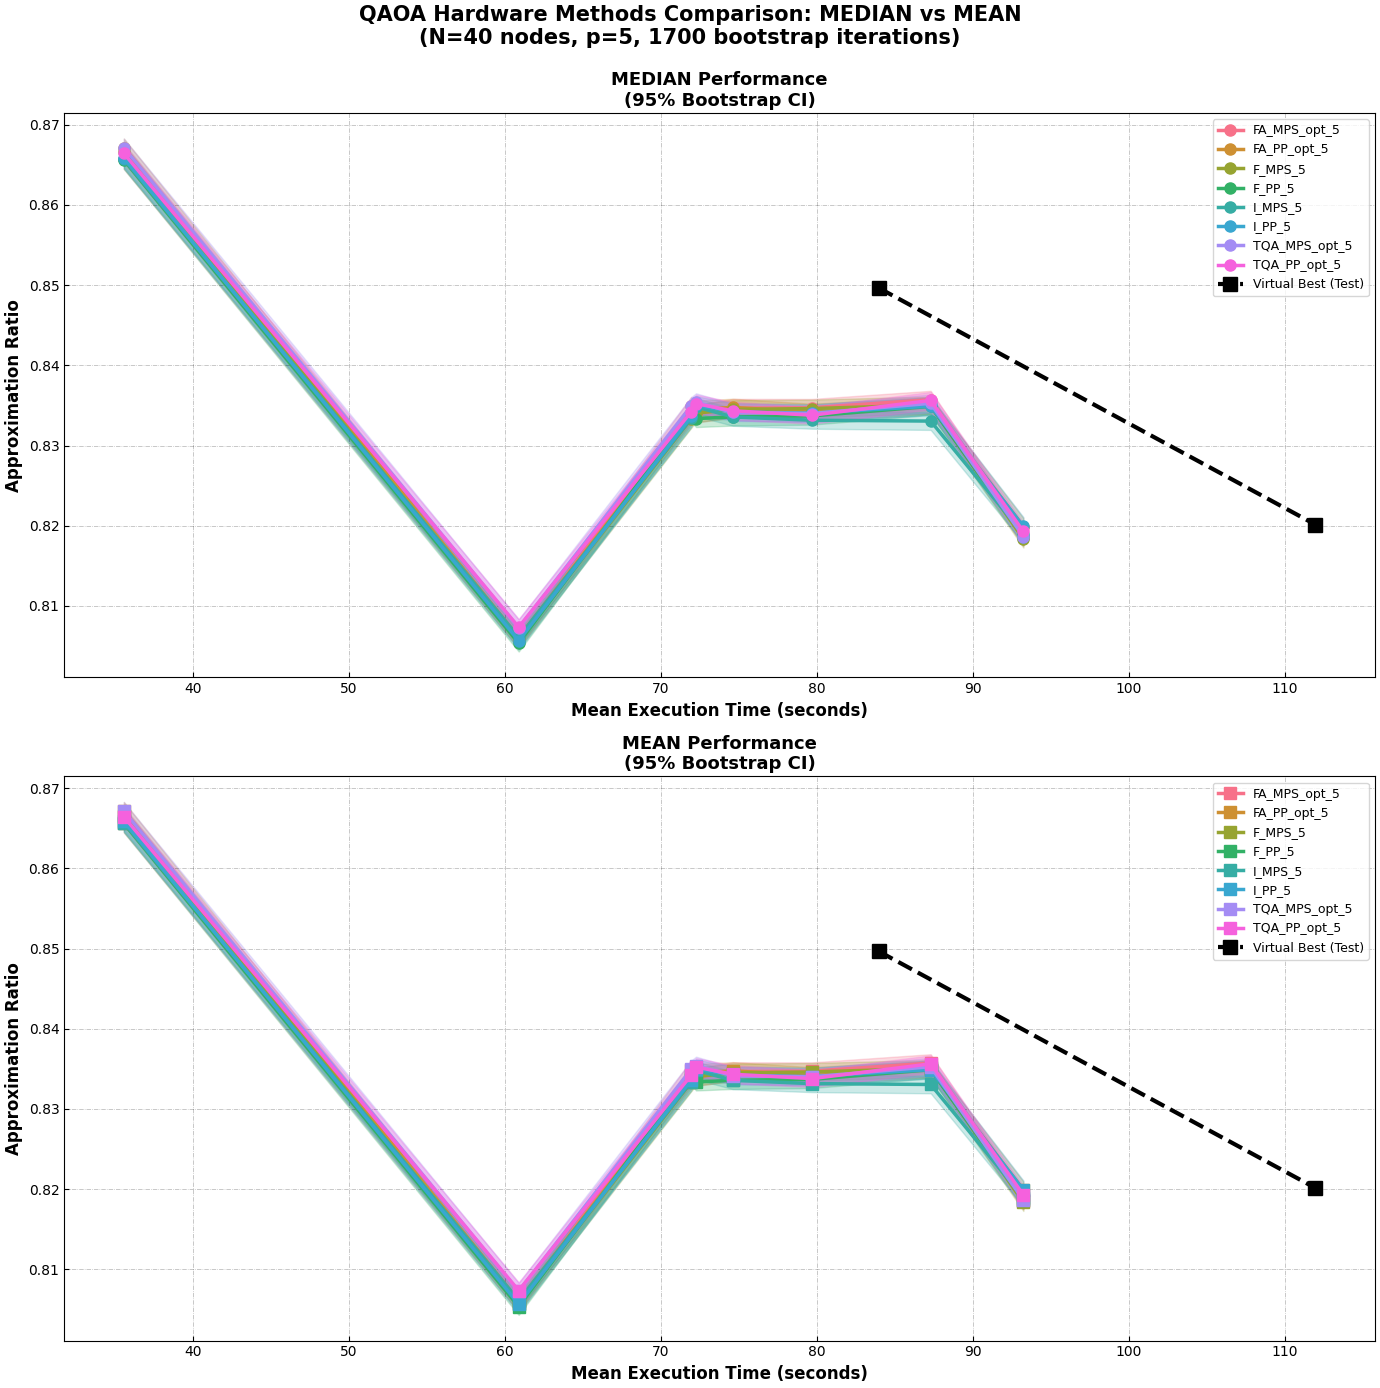


✓ Plot generated and saved
  File: plots/hardware_methods_median_vs_mean.png

📊 Comparing 8 methods (Median vs Mean):
  • FA_MPS_opt_5:
      Median = 0.8330, Mean = 0.8330, Diff = +0.0000
  • FA_PP_opt_5:
      Median = 0.8332, Mean = 0.8332, Diff = +0.0000
  • F_MPS_5:
      Median = 0.8328, Mean = 0.8328, Diff = +0.0000
  • F_PP_5:
      Median = 0.8324, Mean = 0.8324, Diff = +0.0000
  • I_MPS_5:
      Median = 0.8323, Mean = 0.8323, Diff = +0.0000
  • I_PP_5:
      Median = 0.8329, Mean = 0.8329, Diff = +0.0000
  • TQA_MPS_opt_5:
      Median = 0.8334, Mean = 0.8334, Diff = +0.0000
  • TQA_PP_opt_5:
      Median = 0.8333, Mean = 0.8333, Diff = +0.0000

Plot shows:
  • LEFT: Median performance across training instances
  • RIGHT: Mean performance across training instances
  • Colored bands: 95% Bootstrap CI for each method
  • Black dashed: Virtual Best baseline (best on test instances)


In [62]:
# === Step 5: Generate Performance Plots (Median and Mean) ===
print("="*80)
print("Generating Method Comparison Plots with Bootstrap CIs")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('plots', exist_ok=True)

# Get training data
train_data = sb.training_stats.copy()

# Create figure with two plots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))

# Get unique methods and assign colors
methods = sorted(train_data['method'].unique())
colors = sns.color_palette("husl", len(methods))

# ===== LEFT PLOT: MEDIAN =====
for idx, method in enumerate(methods):
    method_data = train_data[train_data['method'] == method].sort_values('resource')
    
    # Plot confidence band (95% Bootstrap CI)
    ax1.fill_between(method_data['resource'],
                    method_data['Stat=Q1_Key=PerfRatio'],
                    method_data['Stat=Q3_Key=PerfRatio'],
                    alpha=0.25, color=colors[idx])
    
    # Plot median line
    ax1.plot(method_data['resource'], method_data['Stat=Median_Key=PerfRatio'],
            color=colors[idx], linewidth=2.5, label=method, 
            marker='o', markersize=8)

# Plot Virtual Best baseline on left (MEDIAN)
baseline_median_data = sb.baseline_median.data.sort_values('resource')
ax1.plot(baseline_median_data['resource'], baseline_median_data['response'],
        color='black', linewidth=3, linestyle='--', 
        label='Virtual Best (Test)', marker='s', markersize=10, zorder=100)

ax1.set_xlabel('Mean Execution Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Approximation Ratio', fontsize=12, fontweight='bold')
ax1.set_title('MEDIAN Performance\n(95% Bootstrap CI)', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# ===== RIGHT PLOT: MEAN =====
for idx, method in enumerate(methods):
    method_data = train_data[train_data['method'] == method].sort_values('resource')
    
    # Plot confidence band (95% Bootstrap CI)
    ax2.fill_between(method_data['resource'],
                    method_data['Stat=Q1_Key=PerfRatio'],
                    method_data['Stat=Q3_Key=PerfRatio'],
                    alpha=0.25, color=colors[idx])
    
    # Plot mean line
    ax2.plot(method_data['resource'], method_data['Stat=Mean_Key=PerfRatio'],
            color=colors[idx], linewidth=2.5, label=method, 
            marker='s', markersize=8)

# Plot Virtual Best baseline on right (MEAN)
baseline_mean_data = sb.baseline_mean.data.sort_values('resource')
ax2.plot(baseline_mean_data['resource'], baseline_mean_data['response'],
        color='black', linewidth=3, linestyle='--', 
        label='Virtual Best (Test)', marker='s', markersize=10, zorder=100)

ax2.set_xlabel('Mean Execution Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Approximation Ratio', fontsize=12, fontweight='bold')
ax2.set_title('MEAN Performance\n(95% Bootstrap CI)', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle('QAOA Hardware Methods Comparison: MEDIAN vs MEAN\n(N=40 nodes, p=5, 1700 bootstrap iterations)', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()

fig.savefig('plots/hardware_methods_median_vs_mean.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Plot generated and saved")
print("  File: plots/hardware_methods_median_vs_mean.png")
print(f"\n📊 Comparing {len(methods)} methods (Median vs Mean):")
for method in methods:
    method_median = train_data[train_data['method'] == method]['Stat=Median_Key=PerfRatio'].mean()
    method_mean = train_data[train_data['method'] == method]['Stat=Mean_Key=PerfRatio'].mean()
    diff = method_mean - method_median
    print(f"  • {method}:")
    print(f"      Median = {method_median:.4f}, Mean = {method_mean:.4f}, Diff = {diff:+.4f}")
print("\nPlot shows:")
print("  • LEFT: Median performance across training instances")
print("  • RIGHT: Mean performance across training instances")
print("  • Colored bands: 95% Bootstrap CI for each method")
print("  • Black dashed: Virtual Best baseline (best on test instances)")

Create a Stochastic Benchmark Object

## 5. Script Generation and Validation

Generate executable scripts based on JSON configuration and repository code, with validation and error handling.

Define Bootstrap Parameters

## 6. Execute Generated Scripts

Run the generated scripts with proper error handling, logging, and output capture for validation and debugging.

In [ ]:
# Check interpolation status and provide alternative if needed
print("\n=== Checking Analysis Status ===")

# Check if interpolation completed successfully
if hasattr(sb, 'bs_results') and sb.bs_results is not None and sb.interp_results.equals(sb.bs_results):
    print(f"Interpolation used Bootstrap results as fallback: {sb.interp_results.shape}")
    print("Sample interpolation results:")
    display(sb.interp_results.head())

elif hasattr(sb, 'interp_results') and sb.interp_results is not None:
    print(f"Interpolation completed successfully: {sb.interp_results.shape}")
    print("Sample interpolation results:")
    display(sb.interp_results.head())
else:
    print("No bootstrap results available - analysis cannot continue")
    
# Add train/test split column if missing
if 'train' not in sb.interp_results.columns: # Train is 1, test is 0
    # Simple random train/test split
    np.random.seed(42)
    train_mask = np.random.random(len(sb.interp_results)) < 0.8
    sb.interp_results['train'] = train_mask.astype(int)

print(f"Bootstrap results prepared as interpolation substitute: {sb.interp_results.shape}")
print("Available columns:", list(sb.interp_results.columns))
print("Sample data:")
display(sb.interp_results.head())


In [ ]:
# Set up and run statistics
print("Running statistics analysis...")
train_test_split = 0.8
# Note: 'Approximation_Ratio' is the response_key, but we use 'PerfRatio' which is automatically created.
metrics = ['Key=PerfRatio', f'Key={resource_col}']  # Use configured resource column
stParams = stats.StatsParameters(metrics=metrics, stats_measures=[stats.Median()])

# The check for single instance is already handled inside run_Stats
sb.run_Stats(stParams, train_test_split)

if hasattr(sb, 'stat_results') and sb.stat_results is not None:
    print("Statistics analysis completed.")
    print(f"Statistics results shape: {sb.stat_results.shape}")
    print(f"Resource metric used: {resource_col}")
    print("Sample statistics results:")
    display(sb.stat_results.head())
else:
    print("Statistics analysis was skipped or failed.")

=== Simplified QAOA Analysis ===
Analysis source: Interpolation or Bootstrap Fallback Data
Data shape: (80, 18)

 All expected columns are available for analysis.

Available metrics: ['Key=Response', 'ConfInt=lower_Key=Response', 'ConfInt=upper_Key=Response', 'Key=PerfRatio', 'ConfInt=lower_Key=PerfRatio', 'ConfInt=upper_Key=PerfRatio', 'Key=MeanTime', 'ConfInt=lower_Key=MeanTime', 'ConfInt=upper_Key=MeanTime', 'Key=SuccProb', 'ConfInt=lower_Key=SuccProb', 'ConfInt=upper_Key=SuccProb']

Metric Summary:
Key=Response:
  Mean: 15.0560
  Std:  0.0487
  Min:  14.9586
  Max:  15.2121
ConfInt=lower_Key=Response:
  Mean: 14.9969
  Std:  0.0487
  Min:  14.9017
  Max:  15.1509
ConfInt=upper_Key=Response:
  Mean: 15.1150
  Std:  0.0487
  Min:  15.0173
  Max:  15.2694
Key=PerfRatio:
  Mean: 0.8331
  Std:  0.0159
  Min:  0.8054
  Max:  0.8672
ConfInt=lower_Key=PerfRatio:
  Mean: 0.8320
  Std:  0.0159
  Min:  0.8043
  Max:  0.8661
ConfInt=upper_Key=PerfRatio:
  Mean: 0.8342
  Std:  0.0159
  Min:  0.

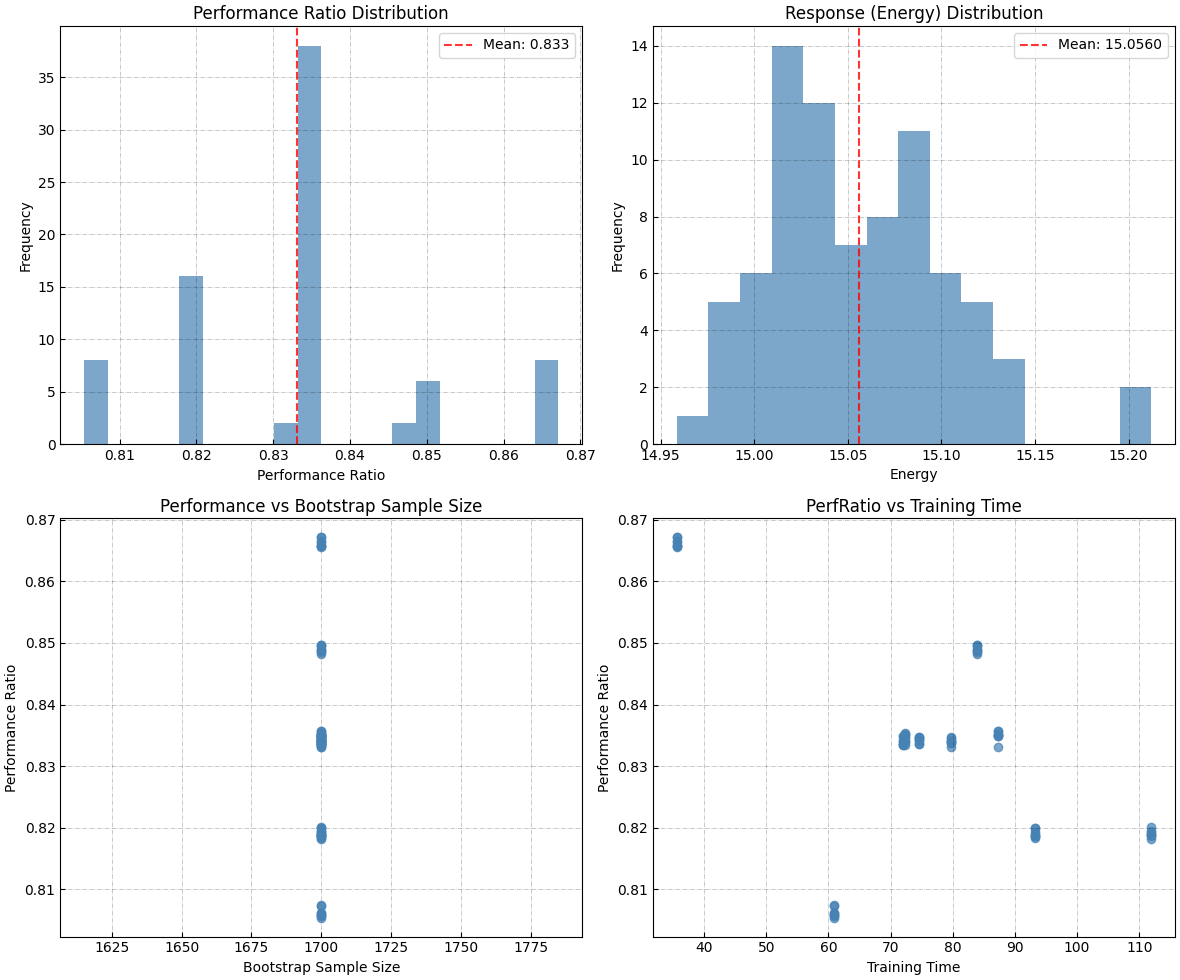


=== QAOA Analysis Summary ===
Mean Performance ratio: 0.8331
Mean Energy: 15.0560

 Analysis completed successfully.


In [70]:
# === Simplified QAOA Analysis using Interpolated or Bootstrap Results ===
print("=== Simplified QAOA Analysis ===")

# Use interpolation results if available (includes fallback bootstrap results)
if hasattr(sb, 'interp_results') and sb.interp_results is not None and not sb.interp_results.empty:
    bs_data = sb.interp_results
    print("Analysis source: Interpolation or Bootstrap Fallback Data")
    print(f"Data shape: {bs_data.shape}")
    
    # === Sanity Check on Available Columns ===
    expected_cols = ['Key=PerfRatio', 'Key=Response', 'Key=MeanTime', 'boots']
    missing_cols = [col for col in expected_cols if col not in bs_data.columns]
    if missing_cols:
        print(f"\n Warning: Missing expected columns: {missing_cols}")
    else:
        print("\n All expected columns are available for analysis.")
    
    # === Metric Analysis ===
    metric_columns = [col for col in bs_data.columns if 'Key=' in col or 'ConfInt=' in col]
    if metric_columns:
        print(f"\nAvailable metrics: {metric_columns}")
        print(f"\nMetric Summary:")
        for col in metric_columns:
            if np.issubdtype(bs_data[col].dtype, np.number):
                print(f"{col}:")
                print(f"  Mean: {bs_data[col].mean():.4f}")
                print(f"  Std:  {bs_data[col].std():.4f}")
                print(f"  Min:  {bs_data[col].min():.4f}")
                print(f"  Max:  {bs_data[col].max():.4f}")
    else:
        print("\n No metric columns found for summary statistics.")
    
    # === Parameter Analysis ===
    param_cols = ['gamma', 'beta']
    available_params = [col for col in param_cols if col in bs_data.columns]
    
    if available_params:
        print(f"\nParameter Analysis (from bootstrap/interp data):")
        for param in available_params:
            if np.issubdtype(bs_data[param].dtype, np.number):
                param_range = bs_data[param].max() - bs_data[param].min()
                print(f"{param}: [{bs_data[param].min():.3f}, {bs_data[param].max():.3f}] (range: {param_range:.3f})")
    else:
        # Fallback to original QAOA data if available
        print(f"\nParameter Analysis (from original QAOA data):")
        if 'qaoa_df' in locals() and not qaoa_df.empty:
            for param in ['gamma', 'beta']:
                if param in qaoa_df.columns:
                    param_range = qaoa_df[param].max() - qaoa_df[param].min()
                    print(f"{param}: [{qaoa_df[param].min():.3f}, {qaoa_df[param].max():.3f}] (range: {param_range:.3f})")
    
    # === Instance Check ===
    n_unique_instances = bs_data.get('instance', pd.Series(['inst=1'])).nunique()
    print(f"\nInstance Analysis: {n_unique_instances} unique instance(s)")
    
    # === Performance Stability ===
    if 'Key=PerfRatio' in bs_data.columns:
        perf_std = bs_data['Key=PerfRatio'].std()
        mean_perf = bs_data['Key=PerfRatio'].mean()
        if mean_perf > 0:
            perf_cv = perf_std / mean_perf * 100
            print(f"Performance stability: CV = {perf_cv:.2f}%")
    else:
        print(" Skipping performance stability analysis (no PerfRatio column).")
    
    # === Visualization ===
    print("\nGenerating diagnostic plots...")
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    plotted = False  # Track if at least one plot was drawn
    
    # Performance ratio distribution
    if 'Key=PerfRatio' in bs_data.columns:
        axes[0,0].hist(bs_data['Key=PerfRatio'], bins=min(20, len(bs_data)//2), alpha=0.7, color='steelblue')
        axes[0,0].set_title('Performance Ratio Distribution')
        axes[0,0].set_xlabel('Performance Ratio')
        axes[0,0].set_ylabel('Frequency')
        axes[0,0].grid(True, alpha=0.3)
        mean_perf = bs_data['Key=PerfRatio'].mean()
        axes[0,0].axvline(mean_perf, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_perf:.3f}')
        axes[0,0].legend()
        plotted = True
    
    # Response distribution
    if 'Key=Response' in bs_data.columns:
        axes[0,1].hist(bs_data['Key=Response'], bins=min(15, len(bs_data)//2), alpha=0.7, color='steelblue')
        axes[0,1].set_title('Response (Energy) Distribution')
        axes[0,1].set_xlabel('Energy')
        axes[0,1].set_ylabel('Frequency')
        axes[0,1].grid(True, alpha=0.3)
        mean_response = bs_data['Key=Response'].mean()
        axes[0,1].axvline(mean_response, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_response:.4f}')
        axes[0,1].legend()
        plotted = True
    
    # Bootstrap sample size effect
    if 'boots' in bs_data.columns and 'Key=PerfRatio' in bs_data.columns:
        axes[1,0].plot(bs_data['boots'], bs_data['Key=PerfRatio'], 'o', alpha=0.7, color='steelblue', markersize=6)
        axes[1,0].set_title('Performance vs Bootstrap Sample Size')
        axes[1,0].set_xlabel('Bootstrap Sample Size')
        axes[1,0].set_ylabel('Performance Ratio')
        axes[1,0].grid(True, alpha=0.3)
        plotted = True
    
    # Time vs Response
    if 'Key=PerfRatio' in bs_data.columns and 'Key=MeanTime' in bs_data.columns:
        axes[1,1].scatter(bs_data['Key=MeanTime'], bs_data['Key=PerfRatio'], alpha=0.7, color='steelblue')
        axes[1,1].set_title('PerfRatio vs Training Time')
        axes[1,1].set_xlabel('Training Time')
        axes[1,1].set_ylabel('Performance Ratio')
        axes[1,1].grid(True, alpha=0.3)
        plotted = True
    
    plt.tight_layout()
    if plotted:
        plt.show()
    else:
        plt.close()
        print(" No plots generated — required columns missing.")
    
    # === Summary ===
    print(f"\n=== QAOA Analysis Summary ===")
    if 'Key=PerfRatio' in bs_data.columns:
        print(f"Mean Performance ratio: {bs_data['Key=PerfRatio'].mean():.4f}")
    if 'Key=Response' in bs_data.columns:
        print(f"Mean Energy: {bs_data['Key=Response'].mean():.4f}")
    if 'qaoa_df' in locals() and not qaoa_df.empty:
        print(f"Original QAOA parameters: gamma={qaoa_df['gamma'].iloc[0]:.3f}, beta={qaoa_df['beta'].iloc[0]:.3f}")
    
    print("\n Analysis completed successfully.")

else:
    print(" No interpolation or bootstrap results available — cannot perform QAOA analysis.")


In [ ]:
# === Check if we should run statistics analysis for single instance ===
if hasattr(sb, 'interp_results') and sb.interp_results is not None and not sb.interp_results.empty:
    n_rows = len(sb.interp_results)
    print(f"Data available for statistics: {n_rows} rows")
    
    # Detect single instance scenario
    n_unique_instances = sb.interp_results.get('instance', pd.Series(['inst=1'])).nunique()
    
    if n_unique_instances == 1 or n_rows <= 5:
        print("\nSingle instance detected - statistics analysis provides limited value")
        print("Skipping statistics analysis for single instance case")
        print("Reason: Insufficient data for meaningful train/test split or only one instance available")
        
        # Set empty results to indicate statistics was skipped
        sb.stat_results = None
        print("Statistics analysis skipped")
        
    else:
        # Multiple instances - run full statistics
        print("\nMultiple instances detected - running statistics analysis")
        
        # Set up statistics parameters
        train_test_split = 0.8
        metrics = ['Key=Response', 'Key=PerfRatio', 'Key=SuccProb', 'Key=MeanTime'] # RTT, 'InvPerfRatio'
        stParams = stats.StatsParameters(metrics=metrics, stats_measures=[stats.Median()])
        
        # Disable split validity check to avoid warnings
        original_check = getattr(training, 'check_split_validity', True)
        training.check_split_validity = False
        
        try:
            sb.run_Stats(stParams, train_test_split)
            print("Statistics analysis completed")
            
            if hasattr(sb, 'stat_results') and sb.stat_results is not None:
                print(f"Statistics results shape: {sb.stat_results.shape}")
                print("Sample statistics results:")
                display(sb.stat_results.head())
            else:
                print("No statistics results available")
                
        except Exception as e:
            print(f"Statistics analysis failed: {e}")
            import traceback
            traceback.print_exc()
        finally:
            # Restore original setting
            training.check_split_validity = original_check
            
else:
    print("No interpolation or bootstrap fallback results available - cannot run statistics analysis")


In [ ]:
# Check if we should run baseline analysis for single instance
if hasattr(sb, 'interp_results') and sb.interp_results is not None:
    n_rows = len(sb.interp_results)
    print(f"Data available for baseline analysis: {n_rows} rows")
    
    # Check if this is single instance by checking number of rows or unique instances
    n_unique_instances = sb.interp_results.get('instance', pd.Series(['inst=1'])).nunique()
    is_single_instance = n_unique_instances == 1 or n_rows <= 5
    
    if is_single_instance:
        print("Single instance detected - baseline analysis provides limited value")
        print("Skipping baseline analysis for single instance case")
        print("Reason: Baseline comparison requires multiple instances or parameter configurations")
        
        # Set baseline to None to indicate it was appropriately skipped
        sb.baseline = None
        print("Baseline analysis skipped")
        
    else:
        # Multiple instances - run baseline analysis
        print("Multiple instances detected - running baseline analysis")
        
        # Check if train column exists, add if missing
        if 'train' not in sb.interp_results.columns:
            print("Adding train/test split column for baseline analysis...")
            np.random.seed(42)
            train_mask = np.random.random(len(sb.interp_results)) < 0.8
            sb.interp_results['train'] = train_mask.astype(int)
        
        try:
            sb.run_baseline()
            print("Baseline analysis completed")
            
            # Evaluate baseline
            if hasattr(sb, 'baseline') and sb.baseline is not None:
                recipes, _ = sb.baseline.evaluate()
                print(f"Baseline recipes shape: {recipes.shape}")
                print("\nBaseline recipe sample:")
                display(recipes.head())
            else:
                print("No baseline results available")
                
        except Exception as e:
            print(f"Baseline analysis failed: {e}")
            print("This may be due to insufficient data for meaningful baseline comparison")
            import traceback
            traceback.print_exc()
            
else:
    print("No interpolation results available - cannot run baseline analysis")


In [ ]:
# === Final Analysis Summary and Status Report ===
print("\n=== QAOA Stochastic Benchmark Analysis Summary ===")

# Original data visualization
if 'agg_df' in locals() and agg_df is not None and not agg_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # PerfRatio vs training time
    valid_data = agg_df[agg_df['Approximation_Ratio'] != -999]
    if len(valid_data) > 0:
        ax1.scatter(valid_data['MeanTime'], valid_data['Approximation_Ratio'], alpha=0.7, color='blue')
        ax1.set_xlabel('Training Time (s)')
        ax1.set_ylabel('Approximation Ratio')
        ax1.set_title('QAOA Approximation Ratio vs Training Time')
        ax1.grid(True, alpha=0.3)
    
    # Parameter space visualization
    if 'p' in agg_df.columns and 'Approximation_Ratio' in agg_df.columns and len(valid_data) > 0:
        scatter = ax2.scatter(valid_data['p'], valid_data['Approximation_Ratio'],
                             c=valid_data['Approximation_Ratio'], alpha=0.7)
        ax2.set_xlabel('p')
        ax2.set_ylabel('Approximation Ratio')
        ax2.set_title('QAOA Parameter Space')
        ax2.grid(True, alpha=0.3)
        # Plot number of instances on colorbar for each depth
        num_instances = valid_data['p'].value_counts()
        scatter = ax2.scatter(valid_data['p'], valid_data['Approximation_Ratio'],
                             c=num_instances[valid_data['p']].values, alpha=0.7)
        plt.colorbar(scatter, ax=ax2, label='Number of Instances')
    plt.tight_layout()
    plt.show()
    
    # Data summary
    print(f"\nOriginal Data Summary:")
    print(f"Processed {len(agg_df)} QAOA data rows")
    if len(valid_data) > 0:
        # Check if gamma and beta columns exist
        if 'gamma' in valid_data.columns and 'beta' in valid_data.columns:
            print(f"Parameter space: Gamma [{valid_data['gamma'].min():.3f}, {valid_data['gamma'].max():.3f}], "
                  f"Beta [{valid_data['beta'].min():.3f}, {valid_data['beta'].max():.3f}]")
        print(f"Circuit depths (p): {sorted(valid_data['p'].unique())}")
        print(f"Approximation Ratio range: [{valid_data['Approximation_Ratio'].min():.4f}, {valid_data['Approximation_Ratio'].max():.4f}]")
        print(f"Training time range: [{valid_data['MeanTime'].min():.4f}, {valid_data['MeanTime'].max():.4f}] seconds")

# === Analysis Components Status ===
print(f"\n=== Analysis Components Status ===")
completed_components = []
skipped_components = []
failed_components = []

# Bootstrap
if hasattr(sb, 'bs_results') and sb.bs_results is not None:
    completed_components.append('Bootstrap')
    print(f"Bootstrap: COMPLETED ({sb.bs_results.shape[0]} results)")
else:
    failed_components.append('Bootstrap')
    print("Bootstrap: FAILED")

# Interpolation
if hasattr(sb, 'interp_results') and sb.interp_results is not None:
    completed_components.append('Interpolation')
    print(f"Interpolation: COMPLETED ({sb.interp_results.shape[0]} results)")
else:
    failed_components.append('Interpolation')
    print("Interpolation: FAILED")

# Statistics
if hasattr(sb, 'stat_results'):
    if sb.stat_results is not None:
        completed_components.append('Statistics')
        print(f"Statistics: COMPLETED ({sb.stat_results.shape[0]} results)")
    else:
        skipped_components.append('Statistics')
        print("Statistics: SKIPPED (single instance or insufficient data)")
else:
    failed_components.append('Statistics')
    print("Statistics: FAILED")

# Baseline
if hasattr(sb, 'baseline') and sb.baseline is not None:
    completed_components.append('Baseline')
    print("Baseline: COMPLETED")
else:
    # Check if baseline was skipped for single instance
    if (hasattr(sb, 'interp_results') and sb.interp_results is not None and len(sb.interp_results) <= 5):
        skipped_components.append('Baseline')
        print("Baseline: SKIPPED (single instance, limited baseline value)")
    else:
        failed_components.append('Baseline')
        print("Baseline: FAILED")

# Overall status
print(f"\n=== Overall Status ===")
total_components = 4
actual_completed = len(completed_components)
actual_attempted = total_components - len(skipped_components)

print(f"Completed components: {', '.join(completed_components) if completed_components else 'None'}")
if skipped_components:
    print(f"Skipped components: {', '.join(skipped_components)} (appropriate for single instance)")
if failed_components:
    print(f"Failed components: {', '.join(failed_components)}")

# Adjusted completion rate
if actual_attempted > 0:
    completion_rate = actual_completed / actual_attempted * 100
    print(f"Analysis completion rate: {completion_rate:.0f}% ({actual_completed}/{actual_attempted} applicable components)")
else:
    print("No applicable components for analysis")

# Results summary
if completed_components:
    print(f"\nCompleted analysis components: {len(completed_components)}")
else:
    print("\nNo analysis components completed successfully")
